Cell 1 — Load GT Annotations from JSON


In [3]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

# --- Load all GT annotation JSONs ---
GT_DIR = Path("data/annotations")
rows = []
raw_records = []  # keep full 6-field for later

for jf in sorted(GT_DIR.glob("*.json")):
    data = json.loads(jf.read_text(encoding="utf-8"))
    iid  = Path(data.get("image_id", jf.stem + ".jpeg")).name
    for n in data.get("nutrients", []):
        nutrient = str(n.get("nutrient", "")).strip()
        quantity = str(n.get("quantity", "")).strip()
        unit     = str(n.get("unit", "")).strip()
        context  = str(n.get("context", "")).strip()
        nrv      = str(n.get("nrv_percent", "") or "").strip()
        serving  = str(n.get("serving_size", "") or "").strip()

        rows.append({
            "image_id": iid,
            "nutrient": nutrient,
            "quantity": quantity,
            "unit": unit,
            "context": context,
            "nrv_percent": nrv,
            "serving_size": serving,
        })

gt = pd.DataFrame(rows)
print(f"Total GT tuples: {len(gt)}")
print(f"Total images:    {gt['image_id'].nunique()}")
gt.head(10)

Total GT tuples: 866
Total images:    57


,image_id,nutrient,quantity,unit,context,nrv_percent,serving_size
0,1.PNG,Magnesium (gesamt),400,mg,per_daily_dose,107,
1,1.PNG,Magnesiumsalze der Citronensäure,420,mg,per_daily_dose,,
2,1.PNG,Magnesiumoxid,400,mg,per_daily_dose,,
3,1.PNG,Magnesiumbisglycinat,350,mg,per_daily_dose,,
4,1.PNG,Magnesiummalat,333,mg,per_daily_dose,,
5,101.PNG,Energie,1625,kJ,per_100g,,
6,101.PNG,Energie,383,kcal,per_100g,,
7,101.PNG,Fett,0.8,g,per_100g,,
8,101.PNG,- davon gesättigte Fettsäuren,< 0.1,g,per_100g,,
9,101.PNG,Kohlenhydrate,86.1,g,per_100g,,


Cell 2 — Dataset Size Overview


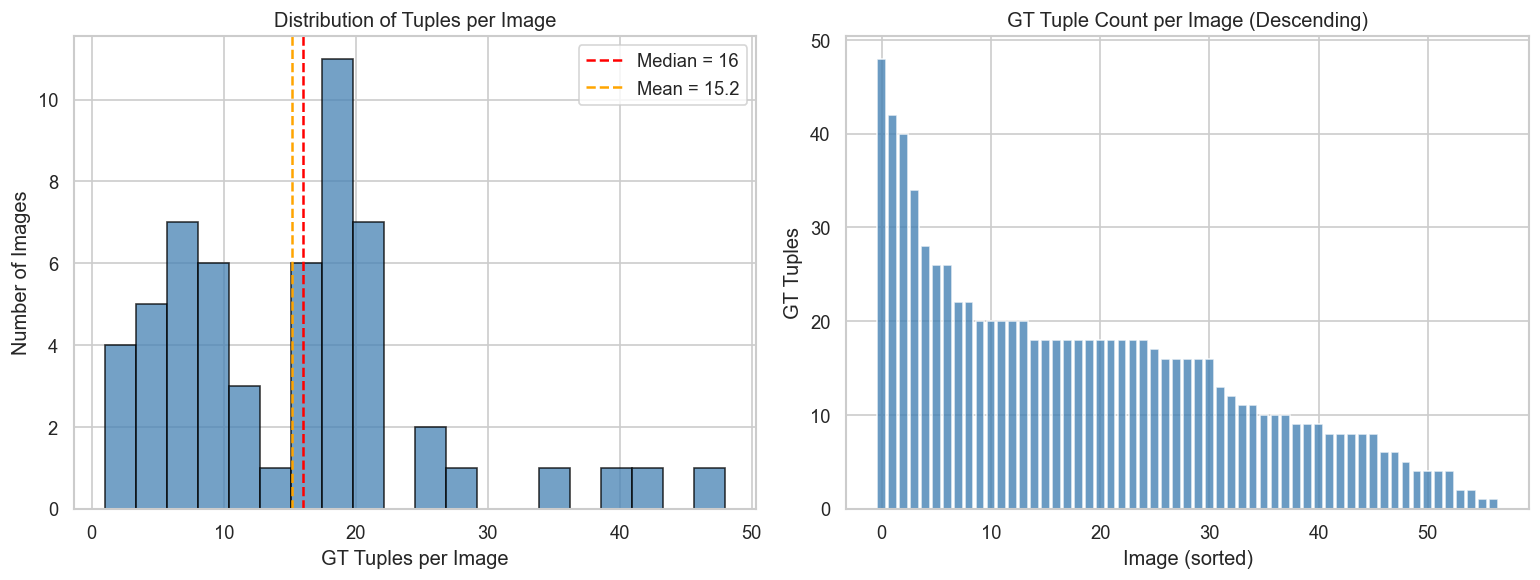

count    57.00
mean     15.19
std       9.90
min       1.00
25%       8.00
50%      16.00
75%      18.00
max      48.00
Name: n_tuples, dtype: float64


In [7]:
tuples_per_img = gt.groupby("image_id").size().reset_index(name="n_tuples")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
axes[0].hist(tuples_per_img['n_tuples'], bins=20, edgecolor='black', color='steelblue', alpha=0.75)
axes[0].axvline(tuples_per_img['n_tuples'].median(), color='red', ls='--',
                label=f"Median = {tuples_per_img['n_tuples'].median():.0f}")
axes[0].axvline(tuples_per_img['n_tuples'].mean(), color='orange', ls='--',
                label=f"Mean = {tuples_per_img['n_tuples'].mean():.1f}")
axes[0].set_xlabel("GT Tuples per Image")
axes[0].set_ylabel("Number of Images")
axes[0].set_title("Distribution of Tuples per Image")
axes[0].legend()

# Sorted bar
sorted_t = tuples_per_img.sort_values("n_tuples", ascending=False)
axes[1].bar(range(len(sorted_t)), sorted_t['n_tuples'], color='steelblue', alpha=0.8)
axes[1].set_xlabel("Image (sorted)")
axes[1].set_ylabel("GT Tuples")
axes[1].set_title("GT Tuple Count per Image (Descending)")

plt.tight_layout()
plt.savefig("gt_01_tuples_per_image.png", bbox_inches='tight')
plt.show()

print(tuples_per_img['n_tuples'].describe().round(2))

In [9]:
# Append serving_size to context (matches evaluator behavior)
gt['context'] = gt.apply(
    lambda r: f"{r['context']} ({r['serving_size']})" 
              if r['serving_size'].strip() not in ('', 'nan') 
              else r['context'],
    axis=1
)

Cell 3 — Context Distribution


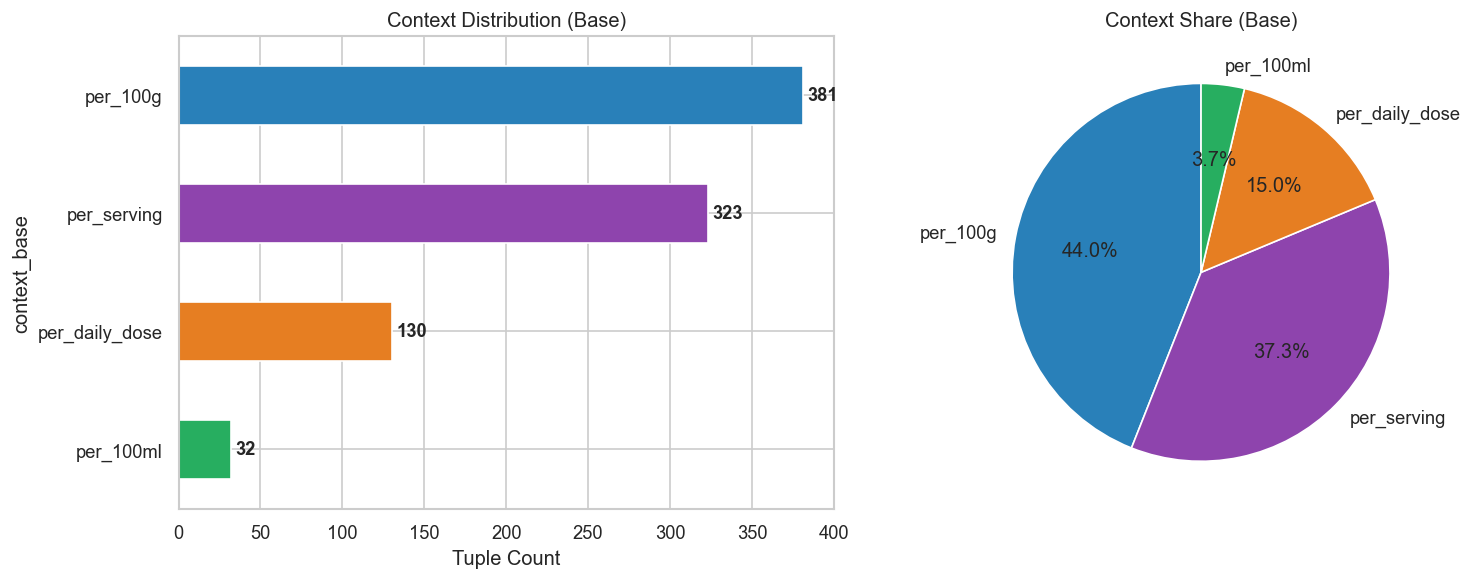

Unique base contexts: 4
context_base
per_100g          381
per_serving       323
per_daily_dose    130
per_100ml          32


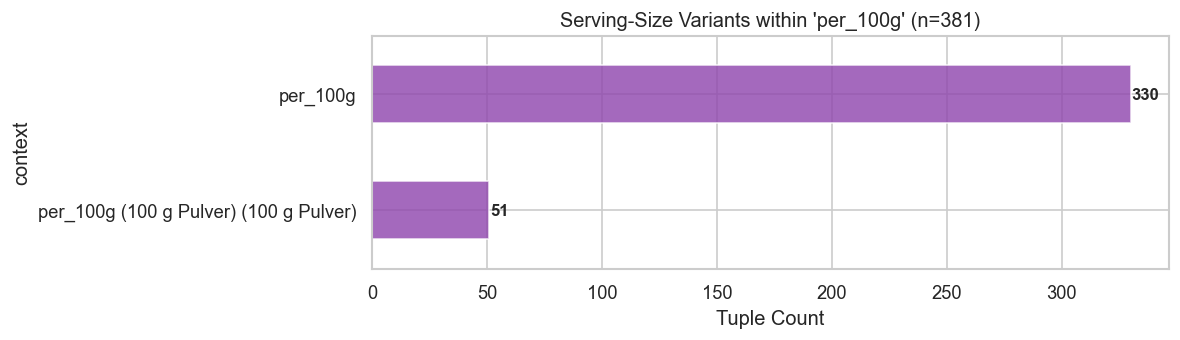

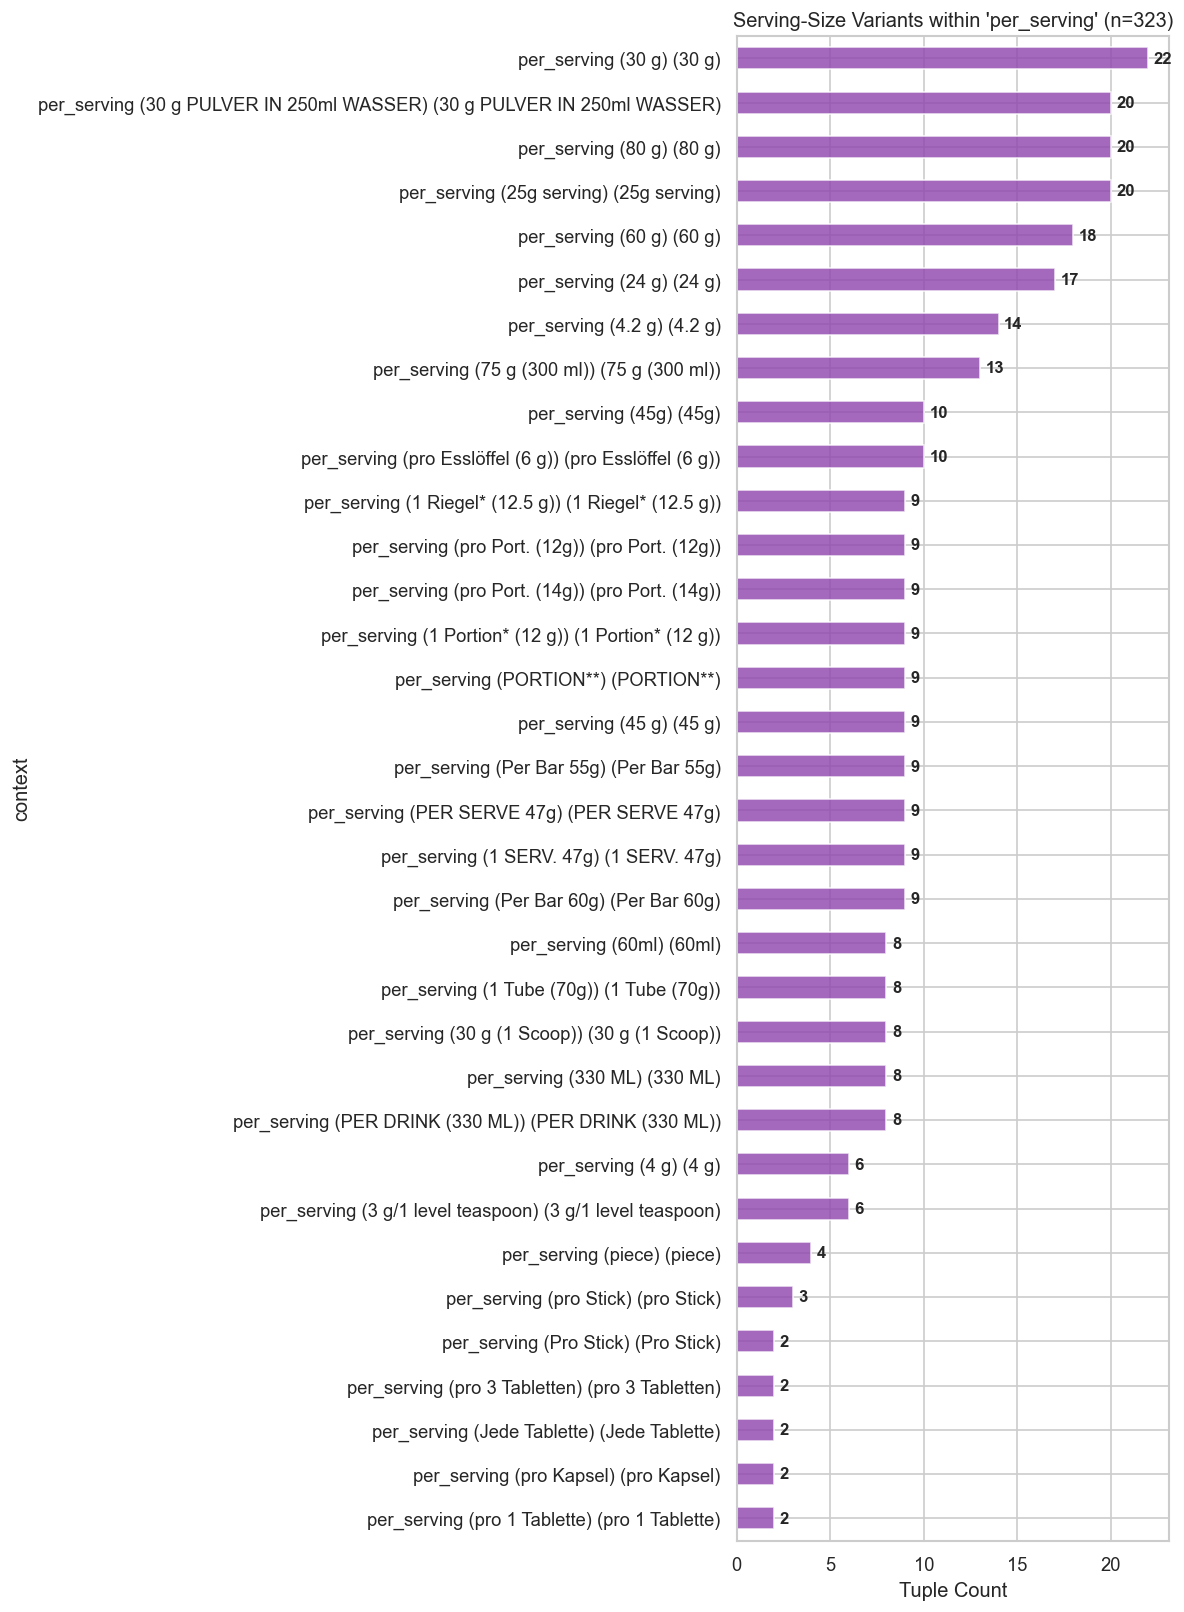

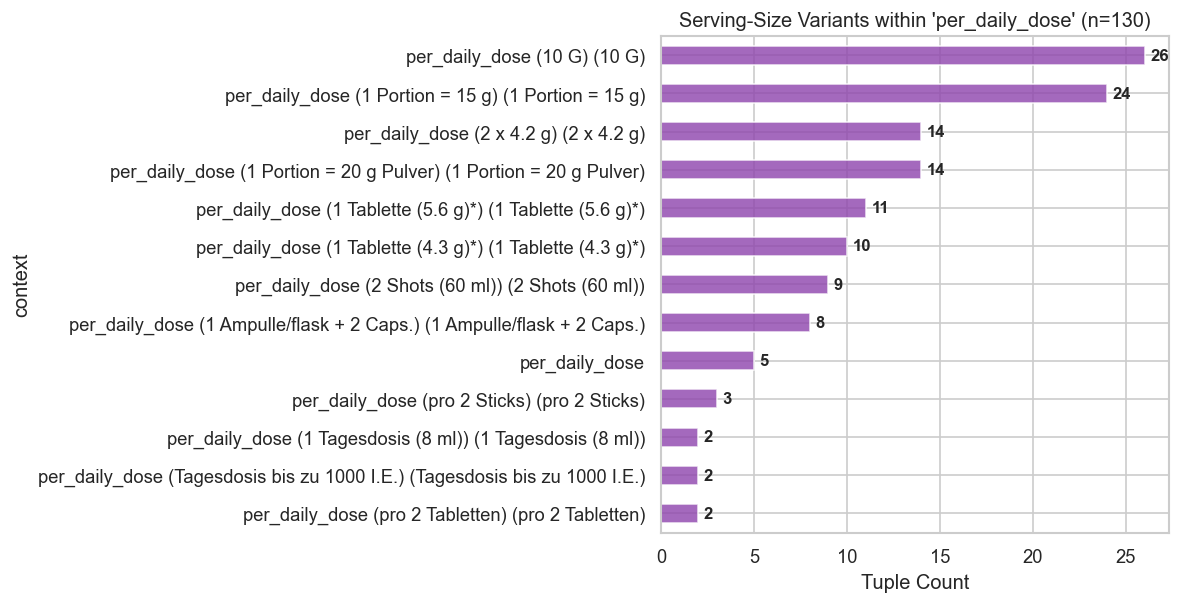

In [10]:
# --- Extract base context (strip serving size parenthetical) ---
import re

gt['context_base'] = gt['context'].apply(
    lambda x: re.sub(r'\s*\(.*\)$', '', str(x)).strip()
)

# ============================================================
# PLOT 1: Clean base-context distribution
# ============================================================
base_counts = gt['context_base'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#2980b9', '#8e44ad', '#e67e22', '#27ae60', '#c0392b', '#1abc9c']
bars = base_counts.plot(kind='barh', ax=axes[0], color=colors[:len(base_counts)])
axes[0].set_xlabel("Tuple Count")
axes[0].set_title("Context Distribution (Base)")
axes[0].invert_yaxis()
for i, val in enumerate(base_counts.values):
    axes[0].text(val + 3, i, str(val), va='center', fontweight='bold', fontsize=11)

base_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90,
                 colors=colors[:len(base_counts)])
axes[1].set_ylabel("")
axes[1].set_title("Context Share (Base)")

plt.tight_layout()
plt.savefig("gt_02a_context_base.png", bbox_inches='tight')
plt.show()

print(f"Unique base contexts: {gt['context_base'].nunique()}")
print(base_counts.to_string())

# ============================================================
# PLOT 2: Serving-size variants within each base context
# ============================================================
for base in base_counts.index:
    subset = gt[gt['context_base'] == base]
    variant_counts = subset['context'].value_counts()
    if len(variant_counts) <= 1:
        continue  # skip if no variants

    fig, ax = plt.subplots(figsize=(10, max(3, len(variant_counts) * 0.4)))
    variant_counts.plot(kind='barh', ax=ax, color='#8e44ad', alpha=0.8)
    ax.set_xlabel("Tuple Count")
    ax.set_title(f"Serving-Size Variants within '{base}' (n={len(subset)})")
    ax.invert_yaxis()
    for i, val in enumerate(variant_counts.values):
        ax.text(val + 0.3, i, str(val), va='center', fontweight='bold', fontsize=10)
    plt.tight_layout()
    plt.savefig(f"gt_02b_{base}_variants.png", bbox_inches='tight')
    plt.show()

In [13]:
gt['qty_numeric'] = pd.to_numeric(
    gt['quantity'].str.replace(',', '.').str.strip('<>~ '), errors='coerce'
)

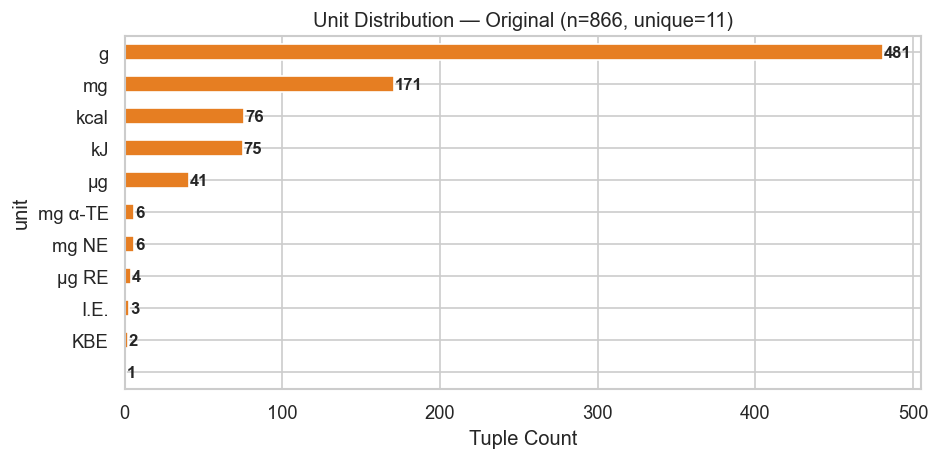

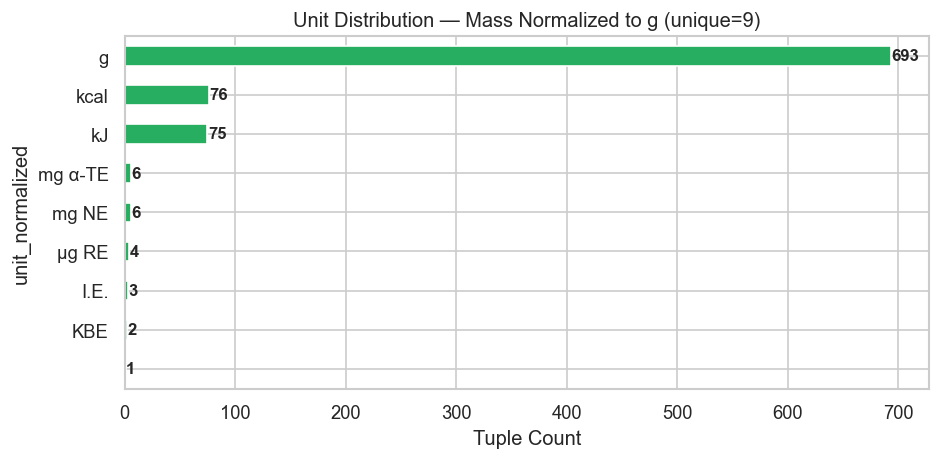

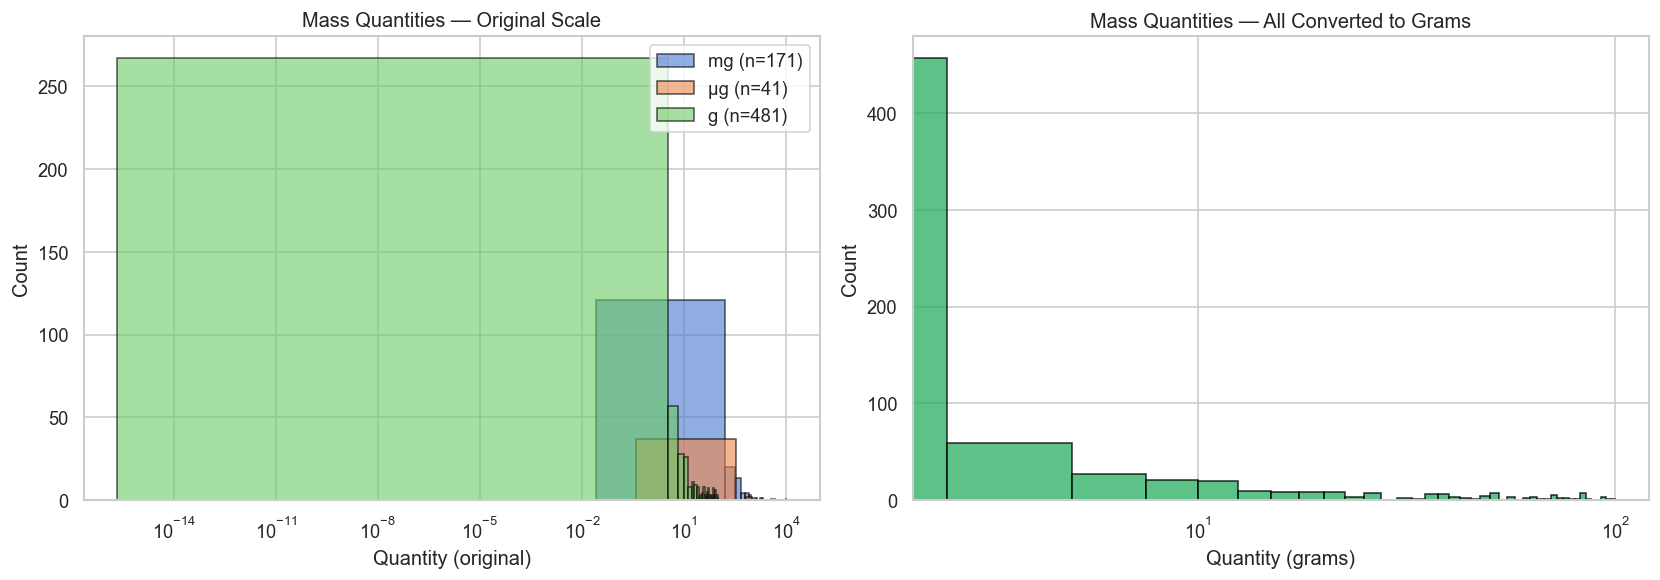

=== Conversion Summary ===
Mass units merged into 'g': ['mg', 'µg', 'ug', 'mcg', 'kg']

Before: 11 unique units
After:  9 unique units

Converted quantity range (grams):
count    693.000000
mean       8.193854
std       18.429346
min        0.000000
25%        0.012000
50%        0.472000
75%        5.100000
max      100.000000


In [15]:
# ============================================================
# PLOT 1: Original unit distribution (as annotated)
# ============================================================
unit_counts = gt['unit'].value_counts()

fig, ax = plt.subplots(figsize=(8, max(4, len(unit_counts) * 0.35)))
unit_counts.plot(kind='barh', ax=ax, color='#e67e22')
ax.set_xlabel("Tuple Count")
ax.set_title(f"Unit Distribution — Original (n={len(gt)}, unique={gt['unit'].nunique()})")
ax.invert_yaxis()
for i, val in enumerate(unit_counts.values):
    ax.text(val + 0.5, i, str(val), va='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig("gt_03a_unit_original.png", bbox_inches='tight')
plt.show()

# ============================================================
# Conversion: normalize mass units → grams
# ============================================================
MASS_TO_GRAMS = {
    'mg':  1e-3,
    'µg':  1e-6,
    'ug':  1e-6,
    'mcg': 1e-6,
    'kg':  1e3,
}

def normalize_unit(unit):
    u = unit.strip().lower()
    if u in MASS_TO_GRAMS:
        return 'g'
    return unit.strip()  # keep original casing for non-mass

gt['unit_normalized'] = gt['unit'].apply(normalize_unit)

# Convert quantity to grams where applicable
gt['qty_in_grams'] = gt.apply(
    lambda r: r['qty_numeric'] * MASS_TO_GRAMS[r['unit'].strip().lower()]
              if r['unit'].strip().lower() in MASS_TO_GRAMS and pd.notna(r['qty_numeric'])
              else r['qty_numeric'],
    axis=1
)

# ============================================================
# PLOT 2: Normalized unit distribution (mass → g)
# ============================================================
norm_counts = gt['unit_normalized'].value_counts()

fig, ax = plt.subplots(figsize=(8, max(4, len(norm_counts) * 0.4)))
norm_counts.plot(kind='barh', ax=ax, color='#27ae60')
ax.set_xlabel("Tuple Count")
ax.set_title(f"Unit Distribution — Mass Normalized to g (unique={gt['unit_normalized'].nunique()})")
ax.invert_yaxis()
for i, val in enumerate(norm_counts.values):
    ax.text(val + 0.5, i, str(val), va='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig("gt_03b_unit_normalized.png", bbox_inches='tight')
plt.show()

# ============================================================
# PLOT 3: Quantity range comparison — original vs grams
# ============================================================
mass_mask = gt['unit'].str.strip().str.lower().isin(MASS_TO_GRAMS.keys()) | (gt['unit'].str.strip().str.lower() == 'g')
mass_subset = gt[mass_mask & gt['qty_numeric'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before: quantity in original units
for u in ['mg', 'µg', 'g']:
    data = mass_subset[mass_subset['unit'].str.strip().str.lower() == u]['qty_numeric']
    if len(data) > 0:
        axes[0].hist(data, bins=30, alpha=0.6, label=f"{u} (n={len(data)})", edgecolor='black')
axes[0].set_xlabel("Quantity (original)")
axes[0].set_ylabel("Count")
axes[0].set_title("Mass Quantities — Original Scale")
axes[0].set_xscale('log')
axes[0].legend()

# After: all converted to grams
axes[1].hist(mass_subset['qty_in_grams'].dropna(), bins=40, color='#27ae60',
             edgecolor='black', alpha=0.75)
axes[1].set_xlabel("Quantity (grams)")
axes[1].set_ylabel("Count")
axes[1].set_title("Mass Quantities — All Converted to Grams")
axes[1].set_xscale('log')

plt.tight_layout()
plt.savefig("gt_03c_mass_comparison.png", bbox_inches='tight')
plt.show()

# Summary
print("=== Conversion Summary ===")
print(f"Mass units merged into 'g': {list(MASS_TO_GRAMS.keys())}")
print(f"\nBefore: {gt['unit'].nunique()} unique units")
print(f"After:  {gt['unit_normalized'].nunique()} unique units")
print(f"\nConverted quantity range (grams):")
print(mass_subset['qty_in_grams'].describe().round(6).to_string())

In [17]:
gt[gt['unit'].str.strip() == ''][['image_id', 'nutrient', 'quantity', 'unit', 'context']]

,image_id,nutrient,quantity,unit,context
541,4.PNG,ENERGY,952,,per_100g


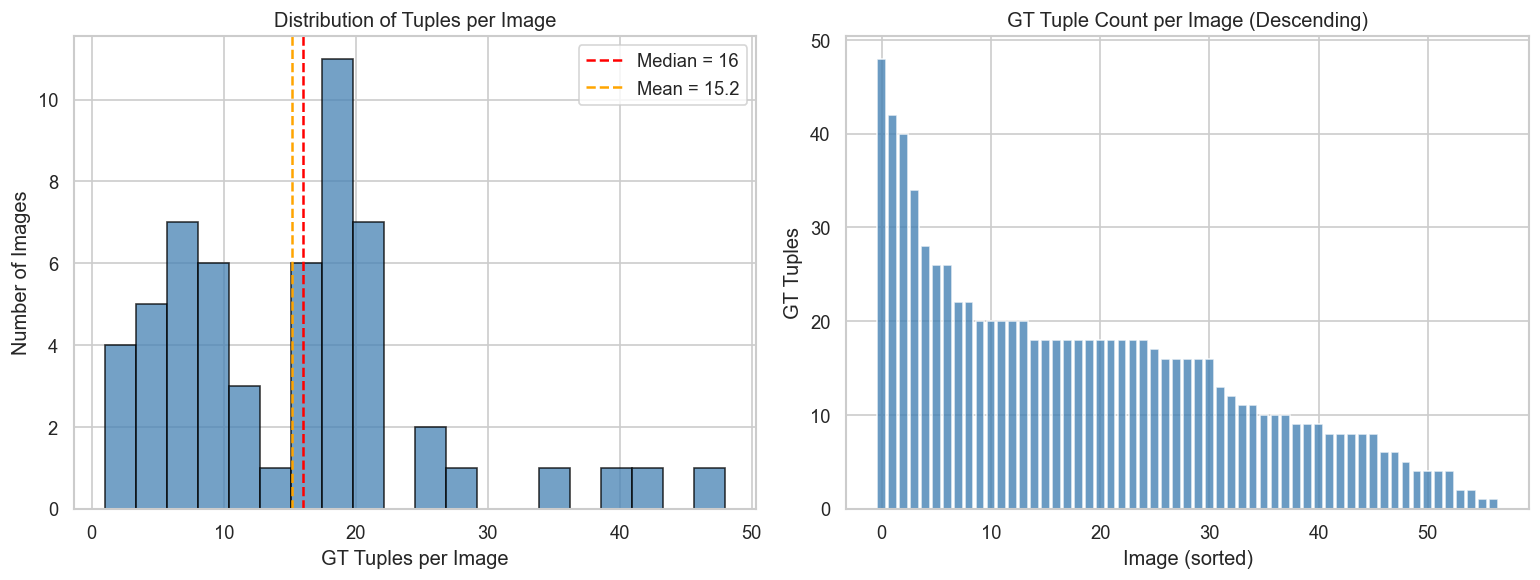

count    57.00
mean     15.19
std       9.90
min       1.00
25%       8.00
50%      16.00
75%      18.00
max      48.00
Name: n_tuples, dtype: float64


In [18]:
tuples_per_img = gt.groupby("image_id").size().reset_index(name="n_tuples")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
axes[0].hist(tuples_per_img['n_tuples'], bins=20, edgecolor='black', color='steelblue', alpha=0.75)
axes[0].axvline(tuples_per_img['n_tuples'].median(), color='red', ls='--',
                label=f"Median = {tuples_per_img['n_tuples'].median():.0f}")
axes[0].axvline(tuples_per_img['n_tuples'].mean(), color='orange', ls='--',
                label=f"Mean = {tuples_per_img['n_tuples'].mean():.1f}")
axes[0].set_xlabel("GT Tuples per Image")
axes[0].set_ylabel("Number of Images")
axes[0].set_title("Distribution of Tuples per Image")
axes[0].legend()

# Sorted bar
sorted_t = tuples_per_img.sort_values("n_tuples", ascending=False)
axes[1].bar(range(len(sorted_t)), sorted_t['n_tuples'], color='steelblue', alpha=0.8)
axes[1].set_xlabel("Image (sorted)")
axes[1].set_ylabel("GT Tuples")
axes[1].set_title("GT Tuple Count per Image (Descending)")

plt.tight_layout()
plt.savefig("gt_01_tuples_per_image.png", bbox_inches='tight')
plt.show()

print(tuples_per_img['n_tuples'].describe().round(2))

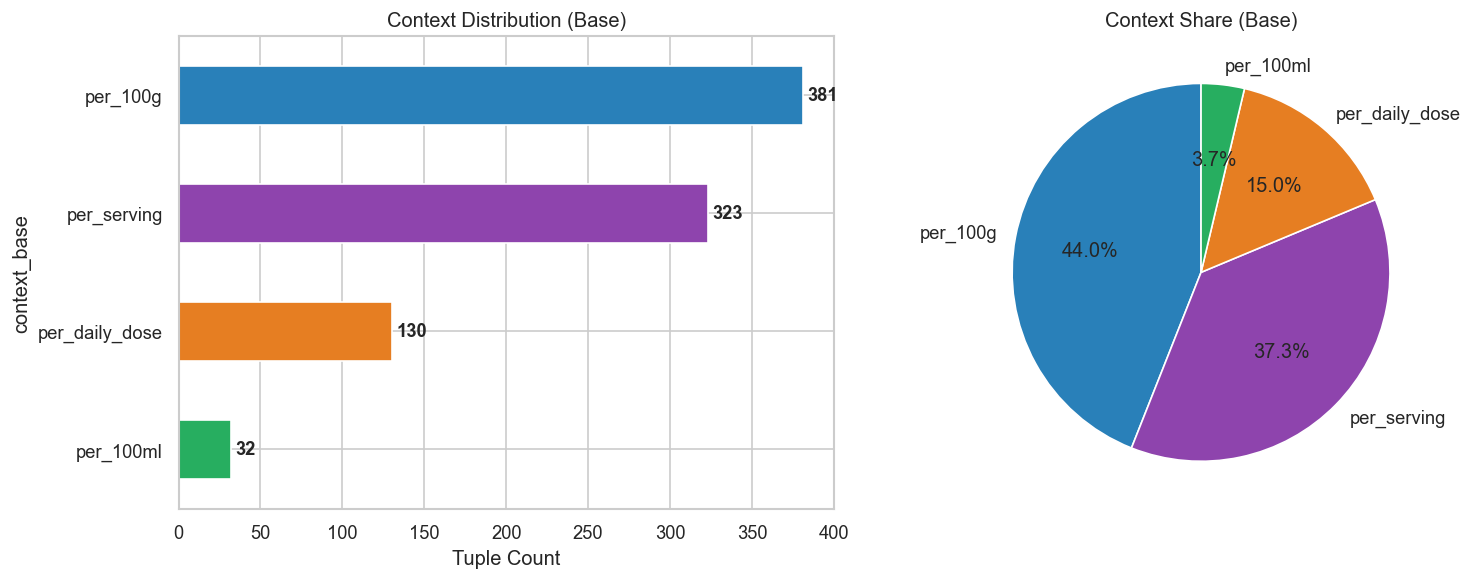

Unique base contexts: 4
context_base
per_100g          381
per_serving       323
per_daily_dose    130
per_100ml          32


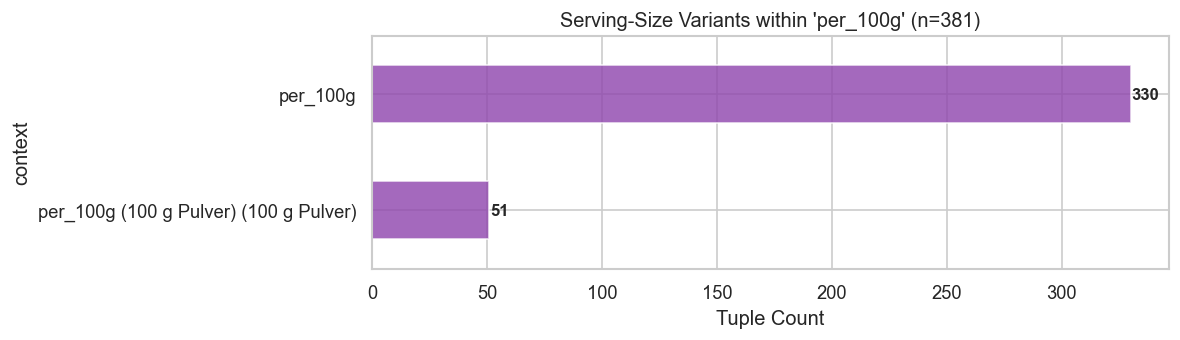

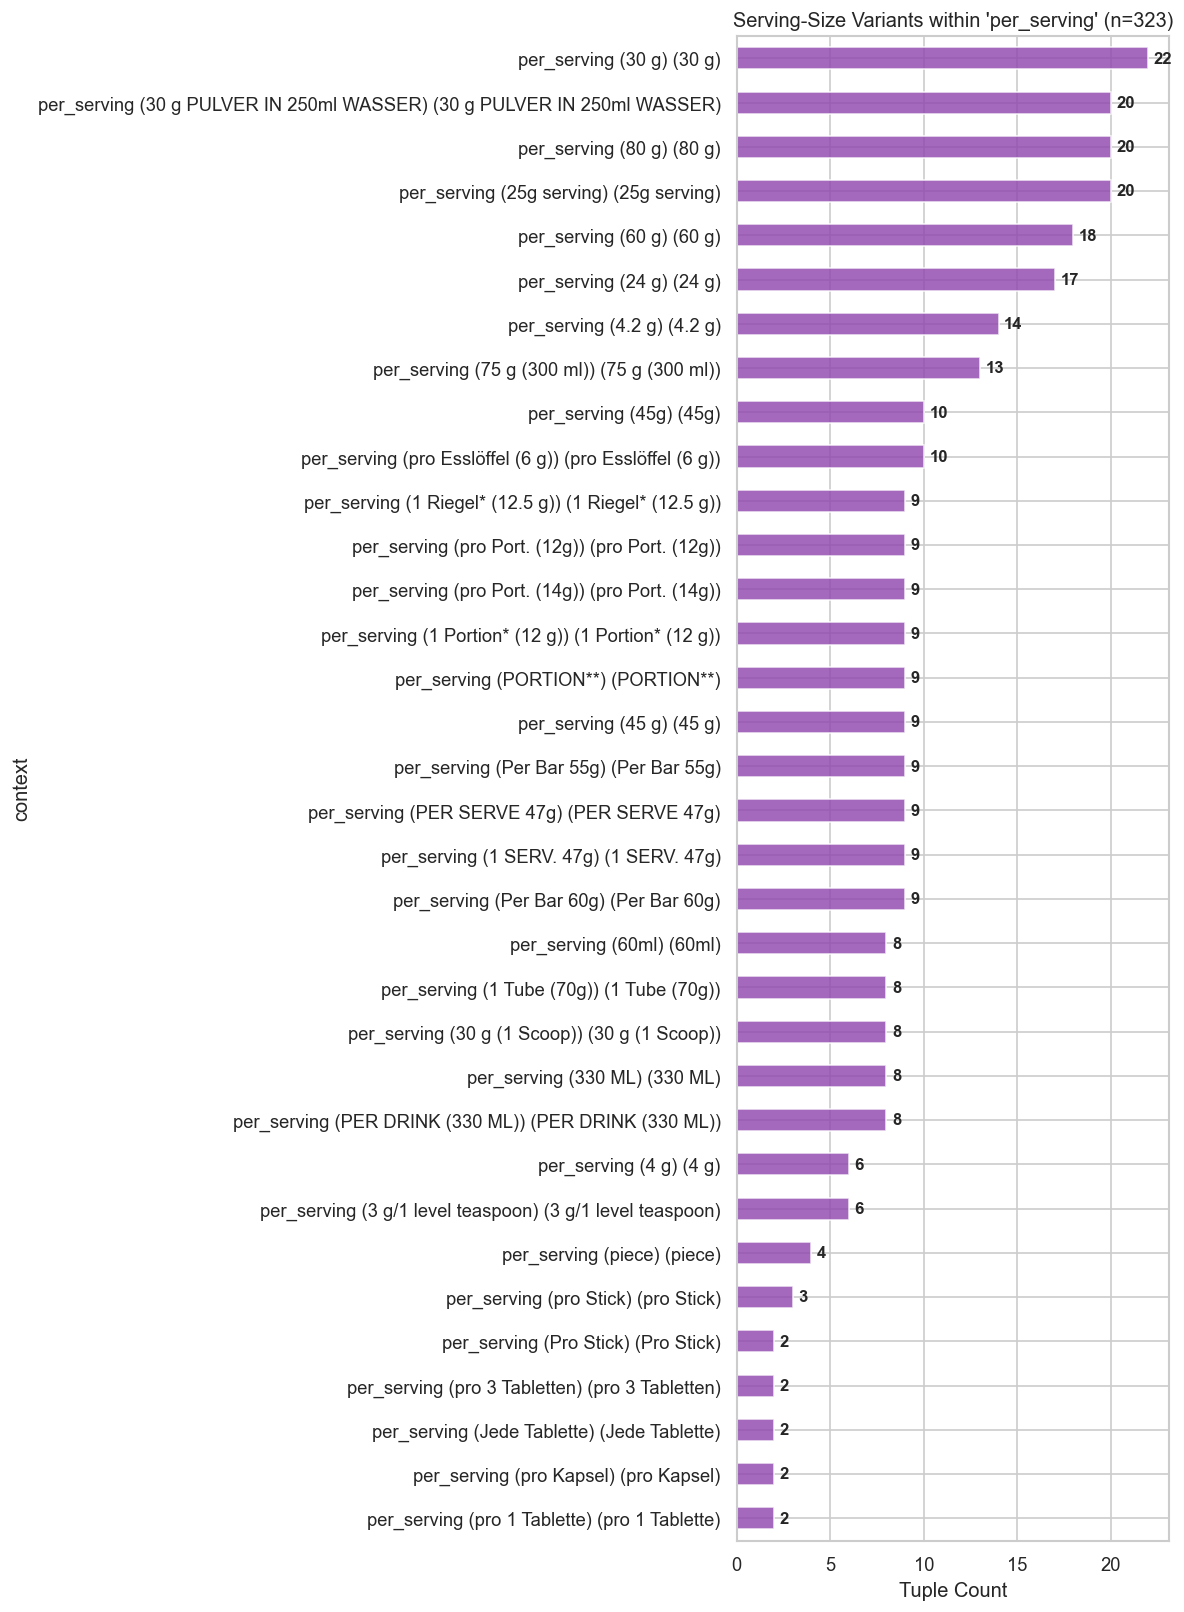

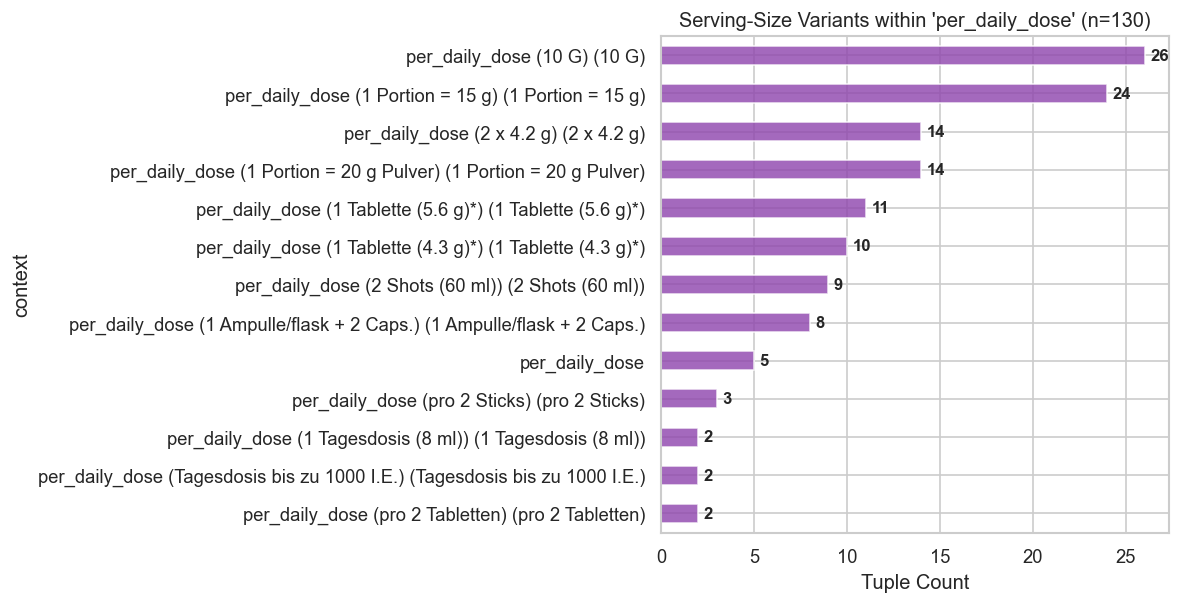

In [19]:
# --- Extract base context (strip serving size parenthetical) ---
import re

gt['context_base'] = gt['context'].apply(
    lambda x: re.sub(r'\s*\(.*\)$', '', str(x)).strip()
)

# ============================================================
# PLOT 1: Clean base-context distribution
# ============================================================
base_counts = gt['context_base'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#2980b9', '#8e44ad', '#e67e22', '#27ae60', '#c0392b', '#1abc9c']
bars = base_counts.plot(kind='barh', ax=axes[0], color=colors[:len(base_counts)])
axes[0].set_xlabel("Tuple Count")
axes[0].set_title("Context Distribution (Base)")
axes[0].invert_yaxis()
for i, val in enumerate(base_counts.values):
    axes[0].text(val + 3, i, str(val), va='center', fontweight='bold', fontsize=11)

base_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90,
                 colors=colors[:len(base_counts)])
axes[1].set_ylabel("")
axes[1].set_title("Context Share (Base)")

plt.tight_layout()
plt.savefig("gt_02a_context_base.png", bbox_inches='tight')
plt.show()

print(f"Unique base contexts: {gt['context_base'].nunique()}")
print(base_counts.to_string())

# ============================================================
# PLOT 2: Serving-size variants within each base context
# ============================================================
for base in base_counts.index:
    subset = gt[gt['context_base'] == base]
    variant_counts = subset['context'].value_counts()
    if len(variant_counts) <= 1:
        continue  # skip if no variants

    fig, ax = plt.subplots(figsize=(10, max(3, len(variant_counts) * 0.4)))
    variant_counts.plot(kind='barh', ax=ax, color='#8e44ad', alpha=0.8)
    ax.set_xlabel("Tuple Count")
    ax.set_title(f"Serving-Size Variants within '{base}' (n={len(subset)})")
    ax.invert_yaxis()
    for i, val in enumerate(variant_counts.values):
        ax.text(val + 0.3, i, str(val), va='center', fontweight='bold', fontsize=10)
    plt.tight_layout()
    plt.savefig(f"gt_02b_{base}_variants.png", bbox_inches='tight')
    plt.show()

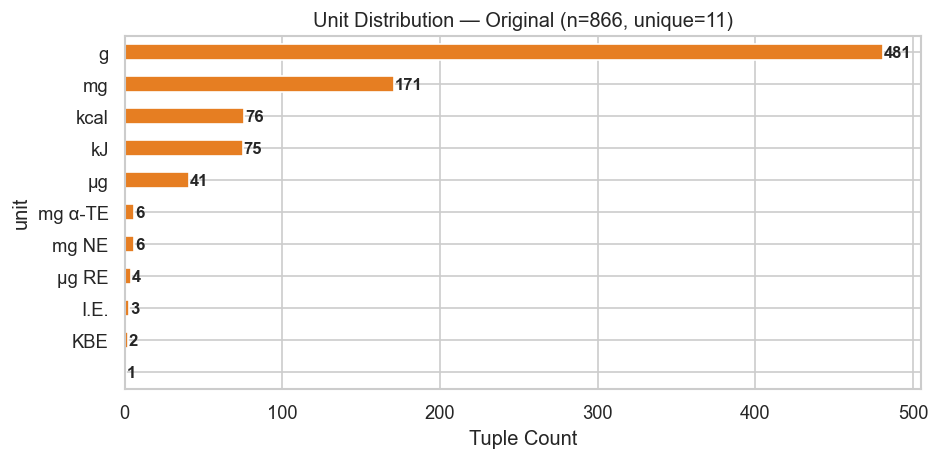

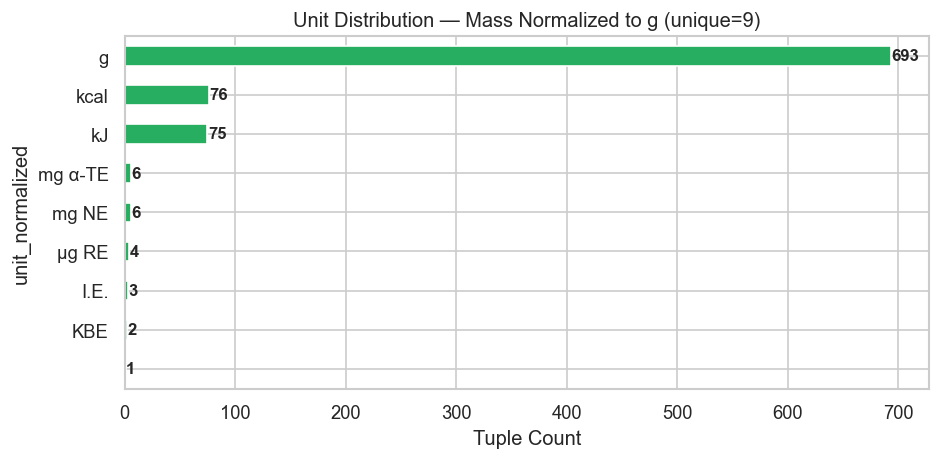

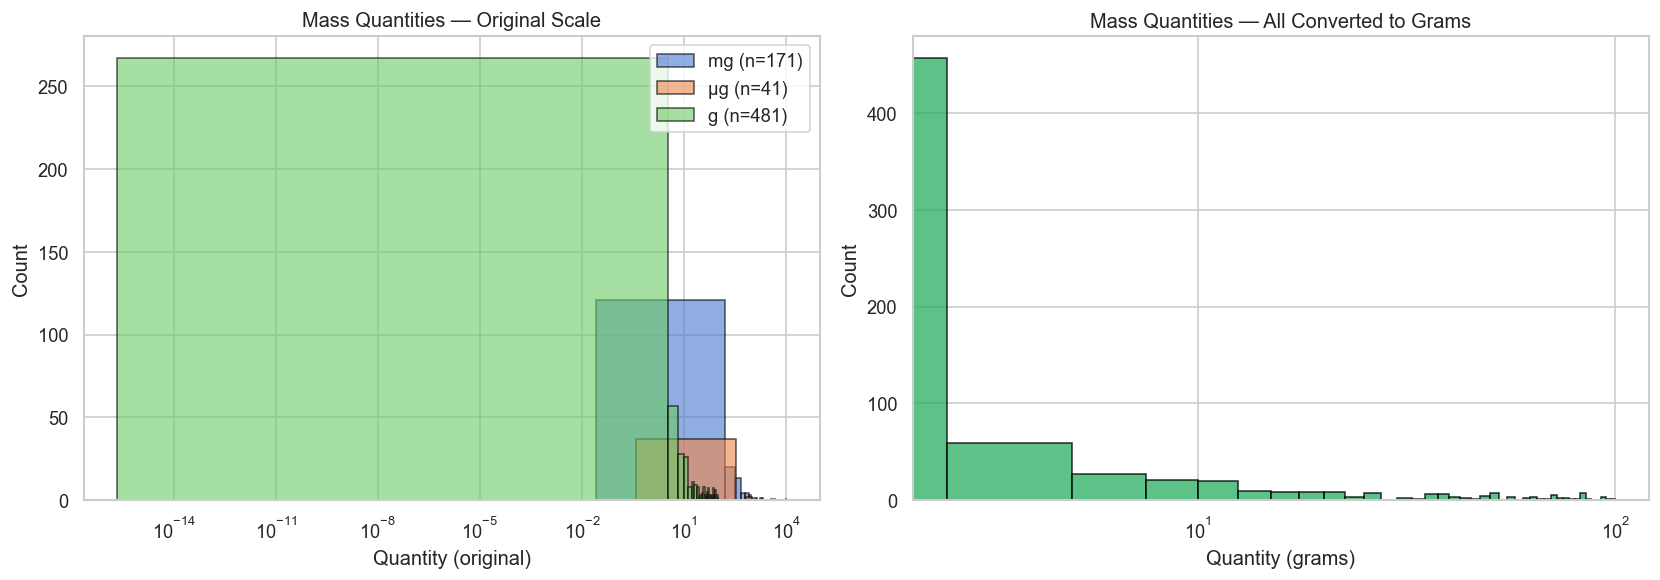

=== Conversion Summary ===
Mass units merged into 'g': ['mg', 'µg', 'ug', 'mcg', 'kg']

Before: 11 unique units
After:  9 unique units

Converted quantity range (grams):
count    693.000000
mean       8.193854
std       18.429346
min        0.000000
25%        0.012000
50%        0.472000
75%        5.100000
max      100.000000


In [20]:
gt['qty_numeric'] = pd.to_numeric(
    gt['quantity'].str.replace(',', '.').str.strip('<>~ '), errors='coerce'
)

# ============================================================
# PLOT 1: Original unit distribution (as annotated)
# ============================================================
unit_counts = gt['unit'].value_counts()

fig, ax = plt.subplots(figsize=(8, max(4, len(unit_counts) * 0.35)))
unit_counts.plot(kind='barh', ax=ax, color='#e67e22')
ax.set_xlabel("Tuple Count")
ax.set_title(f"Unit Distribution — Original (n={len(gt)}, unique={gt['unit'].nunique()})")
ax.invert_yaxis()
for i, val in enumerate(unit_counts.values):
    ax.text(val + 0.5, i, str(val), va='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig("gt_03a_unit_original.png", bbox_inches='tight')
plt.show()

# ============================================================
# Conversion: normalize mass units → grams
# ============================================================
MASS_TO_GRAMS = {
    'mg':  1e-3,
    'µg':  1e-6,
    'ug':  1e-6,
    'mcg': 1e-6,
    'kg':  1e3,
}

def normalize_unit(unit):
    u = unit.strip().lower()
    if u in MASS_TO_GRAMS:
        return 'g'
    return unit.strip()

gt['unit_normalized'] = gt['unit'].apply(normalize_unit)

gt['qty_in_grams'] = gt.apply(
    lambda r: r['qty_numeric'] * MASS_TO_GRAMS[r['unit'].strip().lower()]
              if r['unit'].strip().lower() in MASS_TO_GRAMS and pd.notna(r['qty_numeric'])
              else r['qty_numeric'],
    axis=1
)

# ============================================================
# PLOT 2: Normalized unit distribution (mass → g)
# ============================================================
norm_counts = gt['unit_normalized'].value_counts()

fig, ax = plt.subplots(figsize=(8, max(4, len(norm_counts) * 0.4)))
norm_counts.plot(kind='barh', ax=ax, color='#27ae60')
ax.set_xlabel("Tuple Count")
ax.set_title(f"Unit Distribution — Mass Normalized to g (unique={gt['unit_normalized'].nunique()})")
ax.invert_yaxis()
for i, val in enumerate(norm_counts.values):
    ax.text(val + 0.5, i, str(val), va='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig("gt_03b_unit_normalized.png", bbox_inches='tight')
plt.show()

# ============================================================
# PLOT 3: Quantity range comparison — original vs grams
# ============================================================
unit_lower = gt['unit'].str.strip().str.lower()
mass_mask = unit_lower.isin(list(MASS_TO_GRAMS.keys()) + ['g'])
mass_subset = gt[mass_mask & gt['qty_numeric'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for u in ['mg', 'µg', 'g']:
    data = mass_subset[mass_subset['unit'].str.strip().str.lower() == u]['qty_numeric']
    if len(data) > 0:
        axes[0].hist(data, bins=30, alpha=0.6, label=f"{u} (n={len(data)})", edgecolor='black')
axes[0].set_xlabel("Quantity (original)")
axes[0].set_ylabel("Count")
axes[0].set_title("Mass Quantities — Original Scale")
axes[0].set_xscale('log')
axes[0].legend()

axes[1].hist(mass_subset['qty_in_grams'].dropna(), bins=40, color='#27ae60',
             edgecolor='black', alpha=0.75)
axes[1].set_xlabel("Quantity (grams)")
axes[1].set_ylabel("Count")
axes[1].set_title("Mass Quantities — All Converted to Grams")
axes[1].set_xscale('log')

plt.tight_layout()
plt.savefig("gt_03c_mass_comparison.png", bbox_inches='tight')
plt.show()

print("=== Conversion Summary ===")
print(f"Mass units merged into 'g': {list(MASS_TO_GRAMS.keys())}")
print(f"\nBefore: {gt['unit'].nunique()} unique units")
print(f"After:  {gt['unit_normalized'].nunique()} unique units")
print(f"\nConverted quantity range (grams):")
print(mass_subset['qty_in_grams'].describe().round(6).to_string())

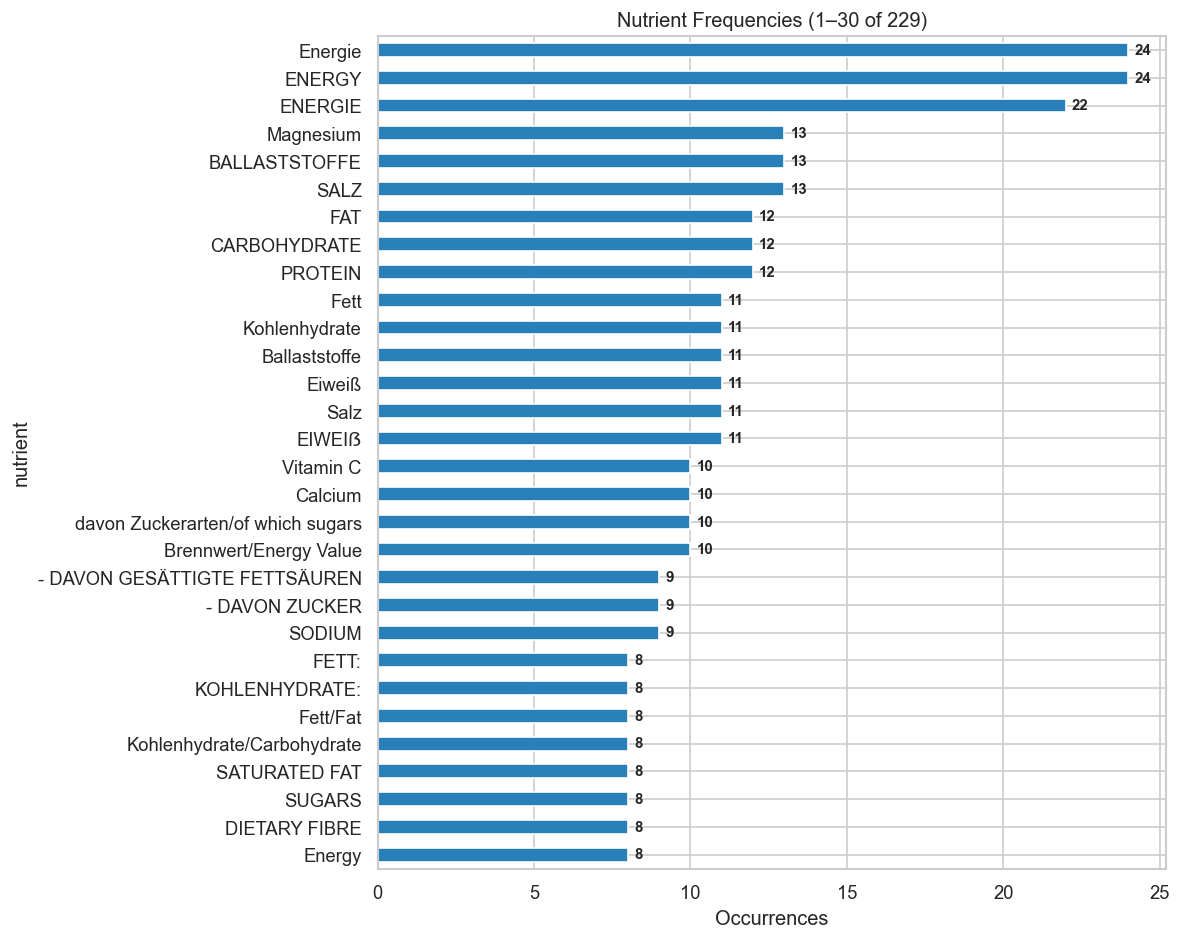

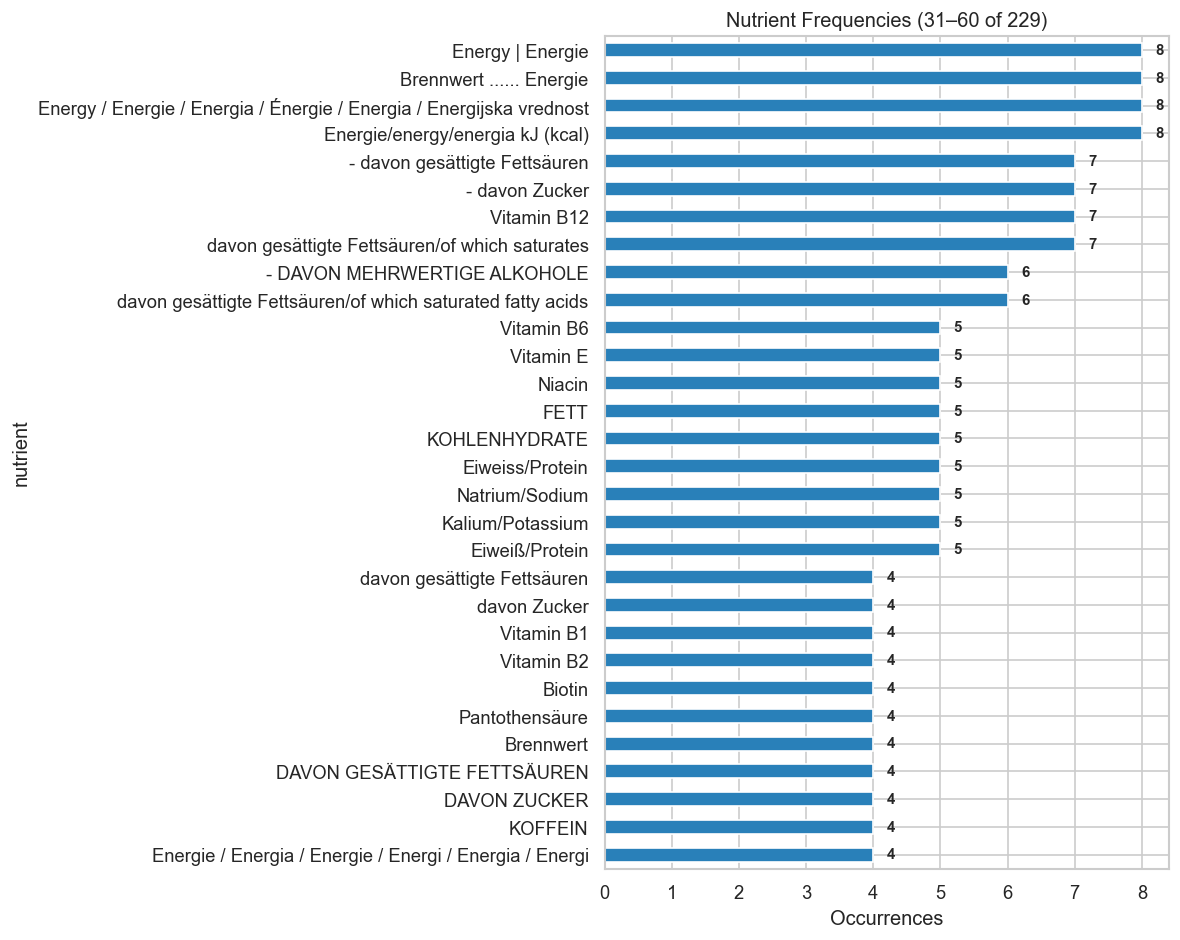

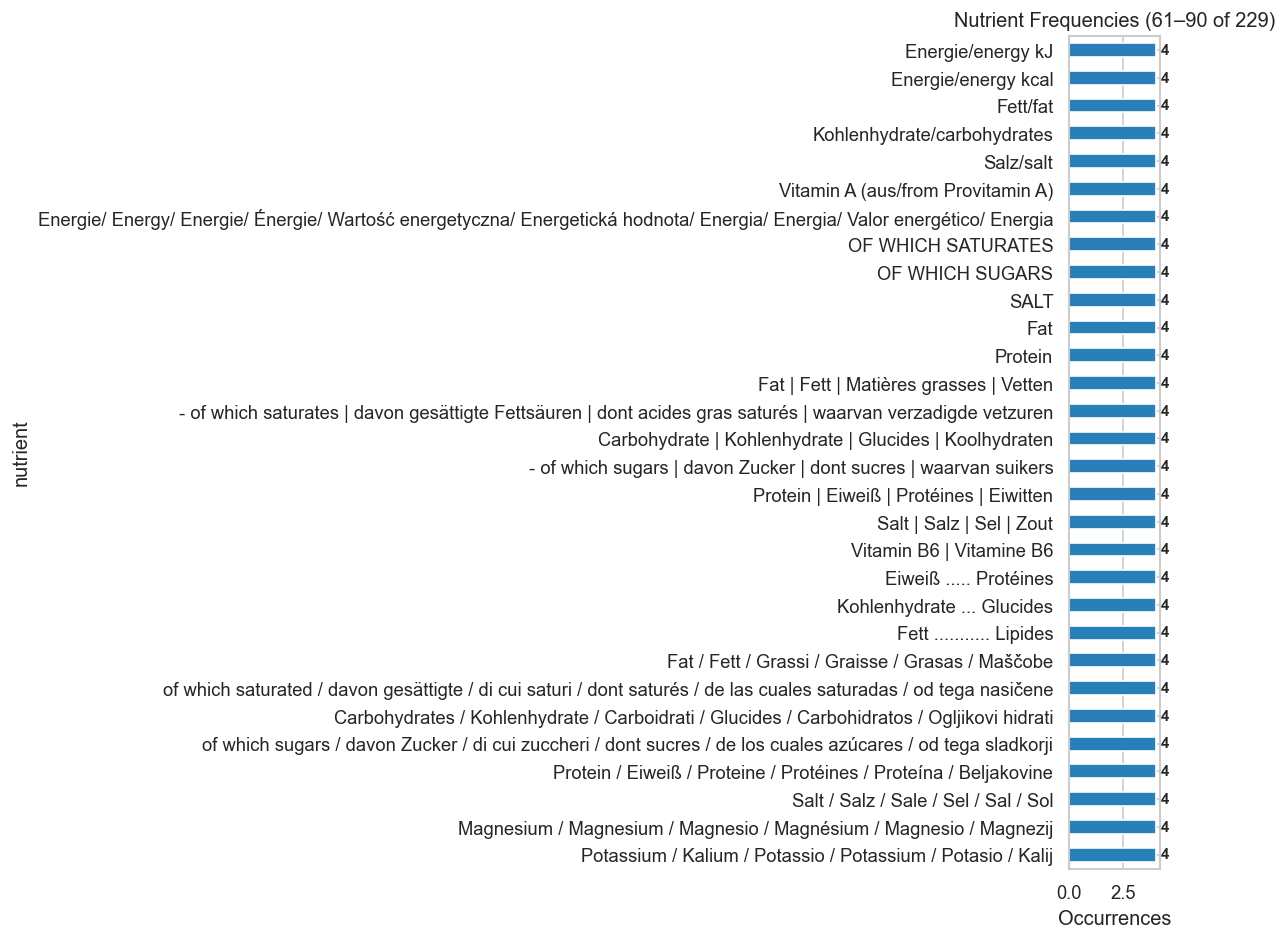

C:\Users\MSAEI\AppData\Local\Temp\ipykernel_15888\2980440436.py:128: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


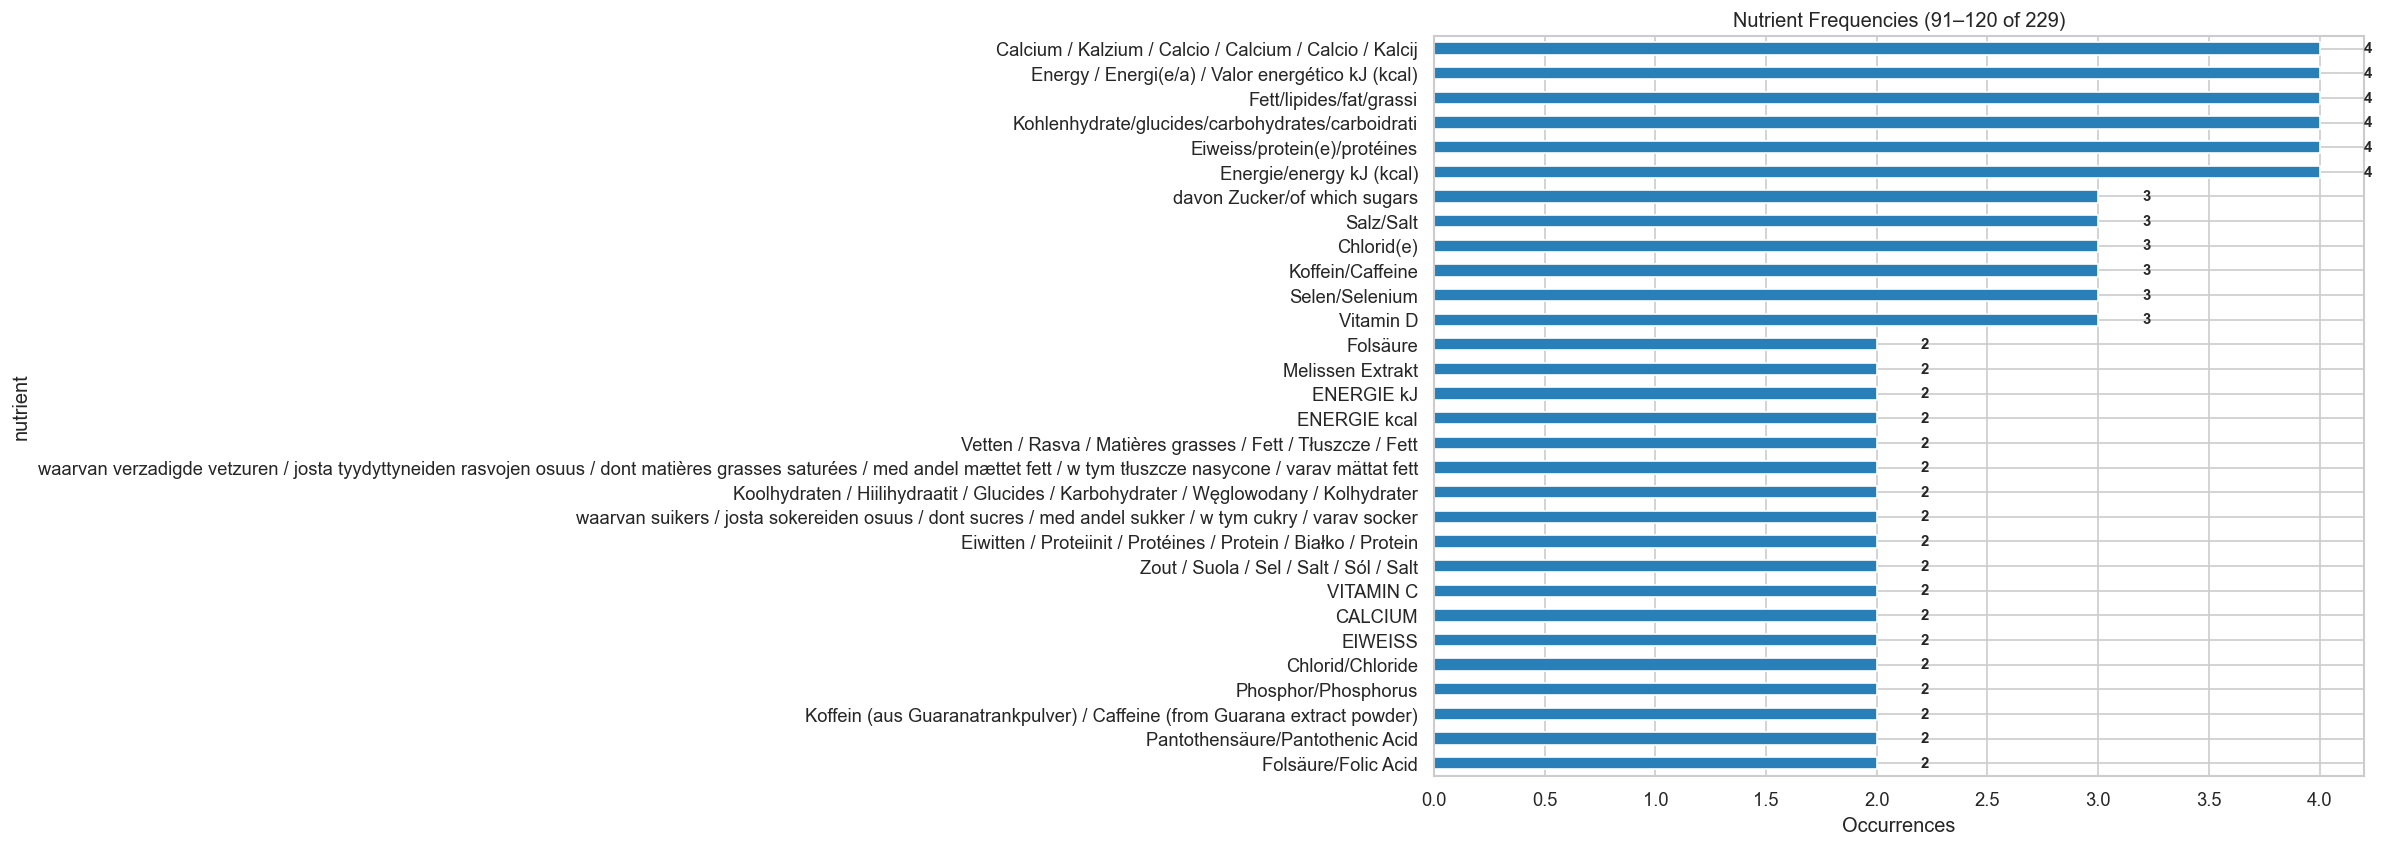

C:\Users\MSAEI\AppData\Local\Temp\ipykernel_15888\2980440436.py:128: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


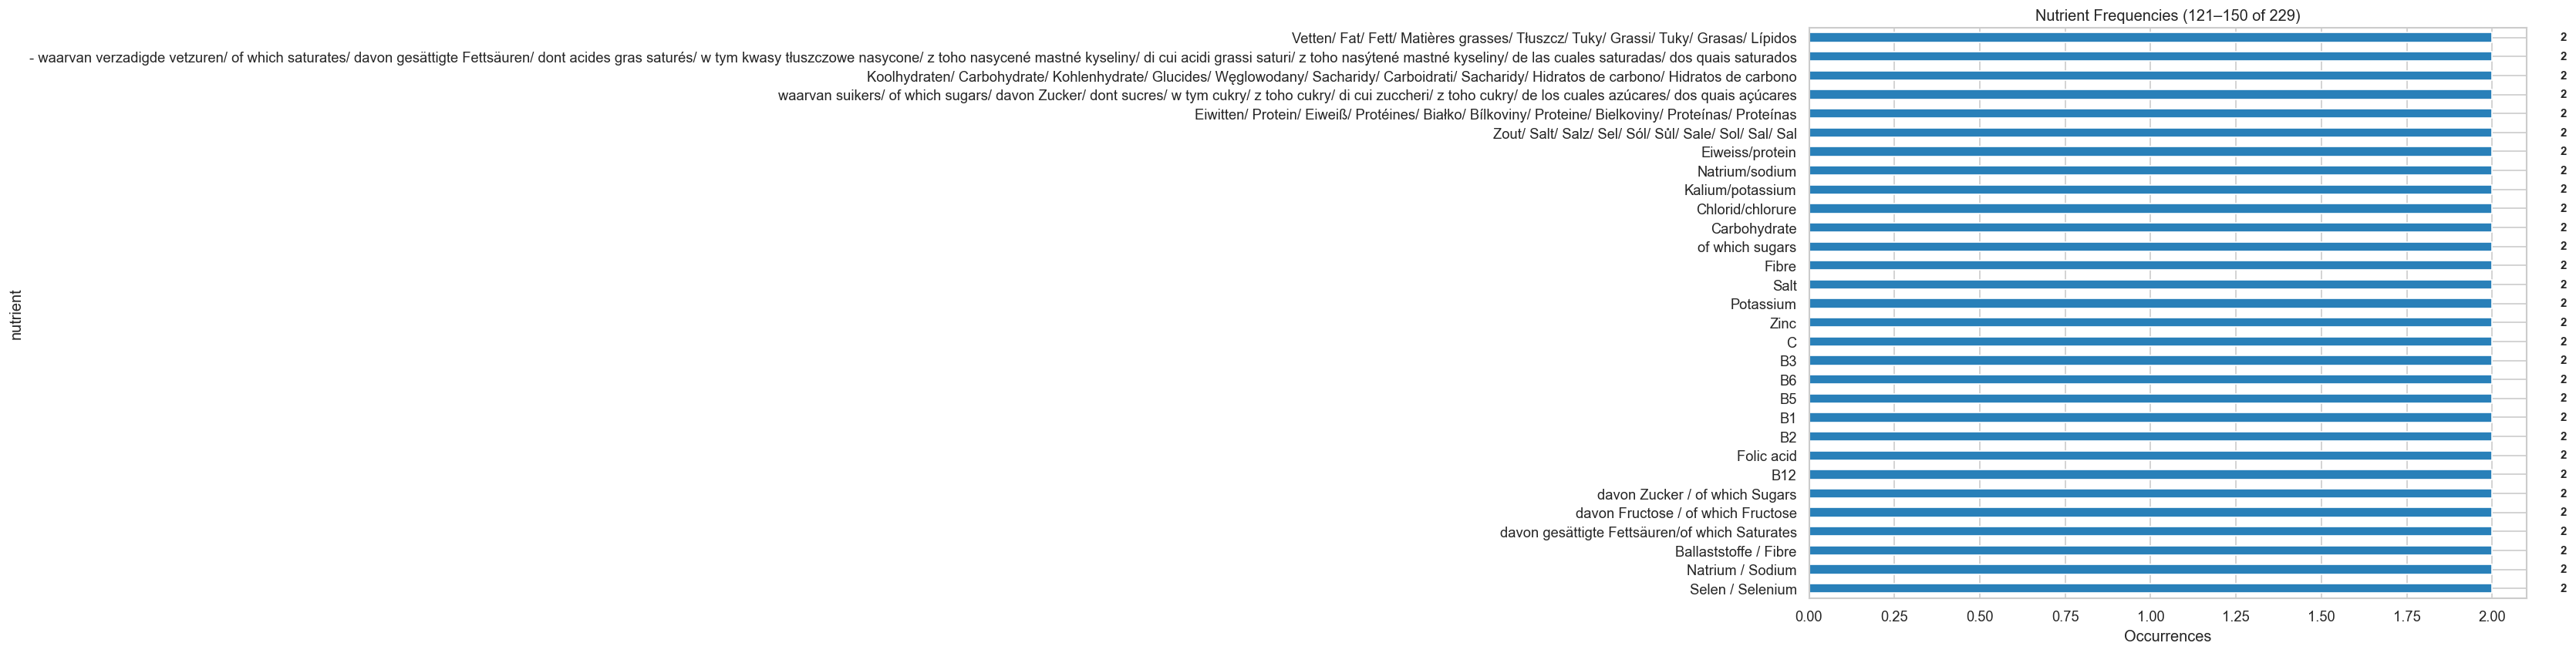

C:\Users\MSAEI\AppData\Local\Temp\ipykernel_15888\2980440436.py:128: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


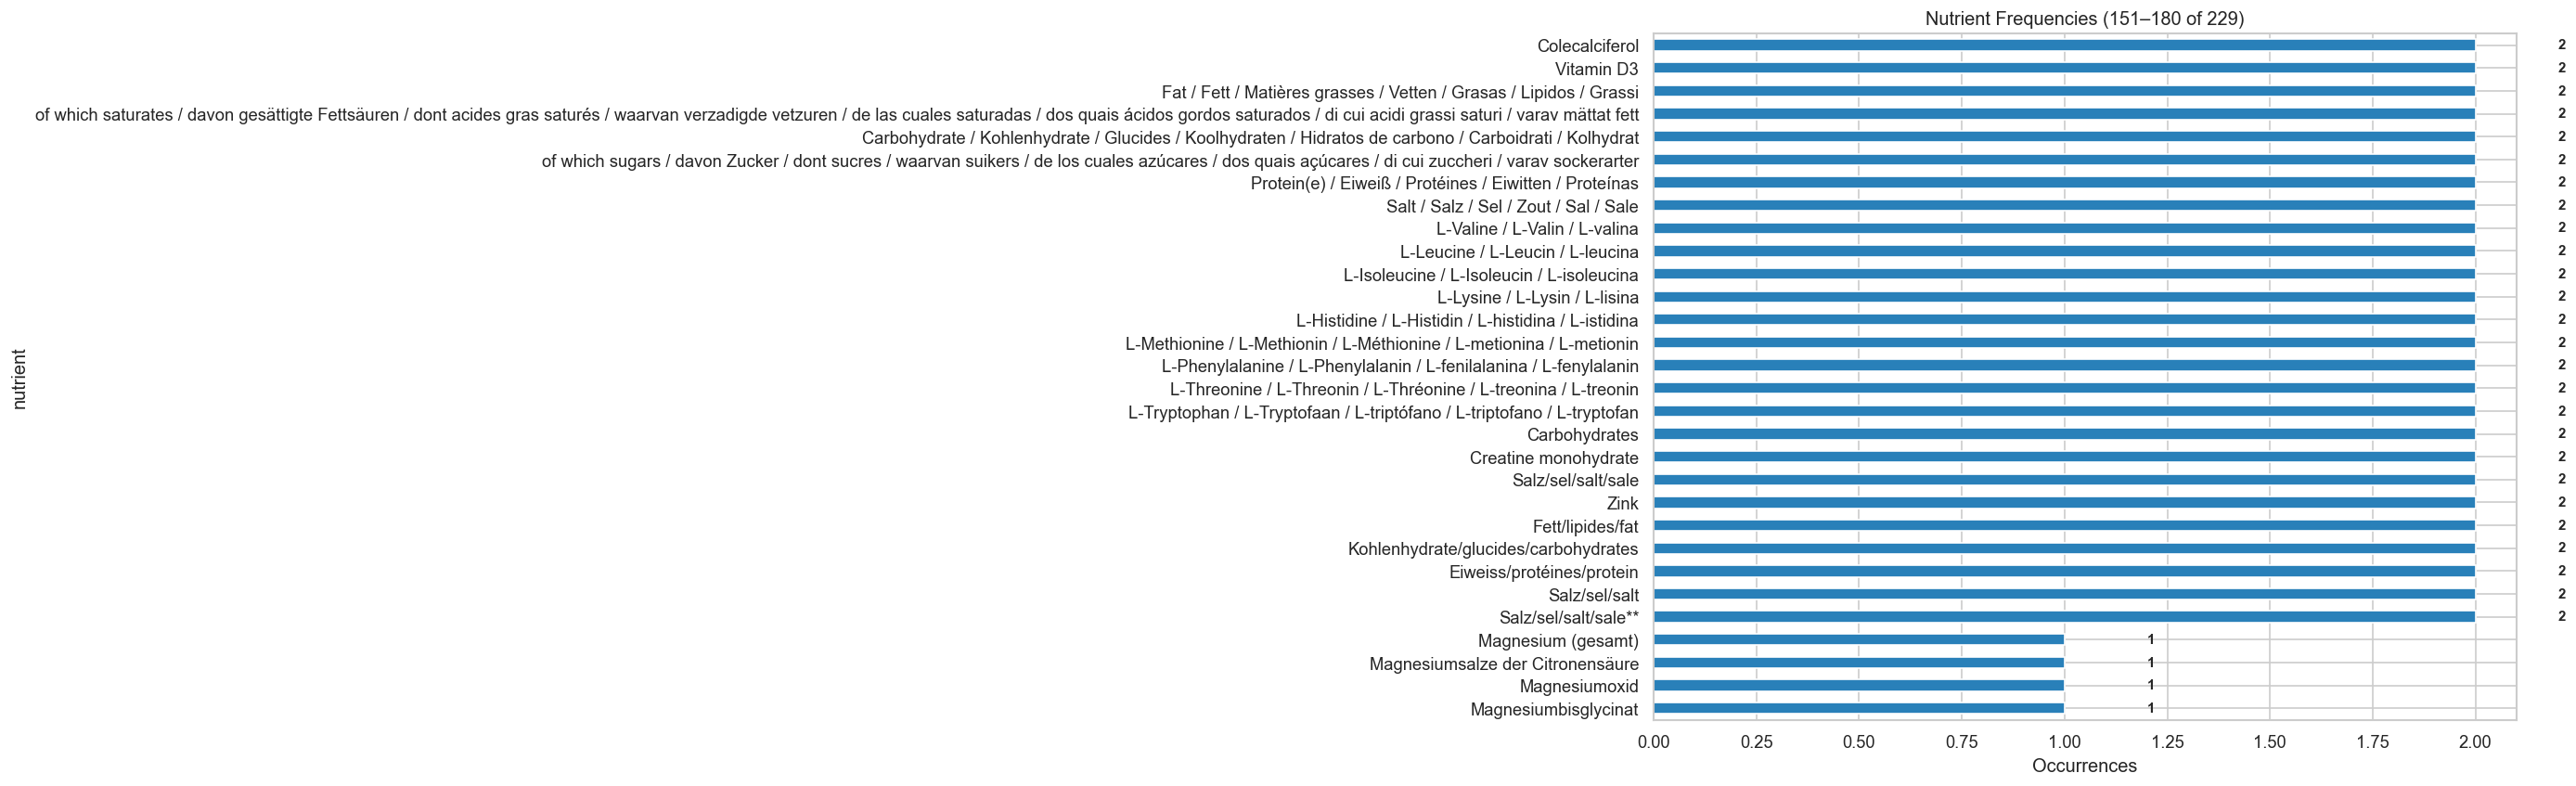

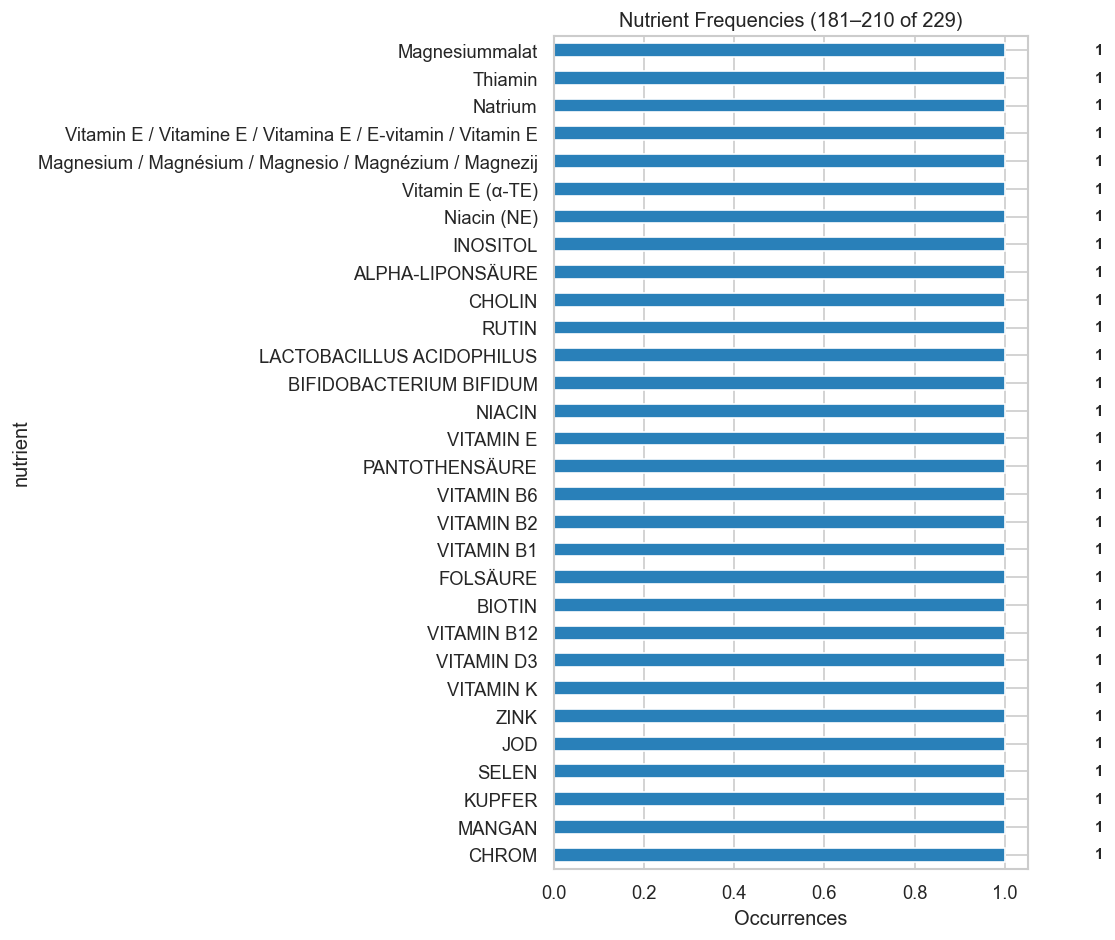

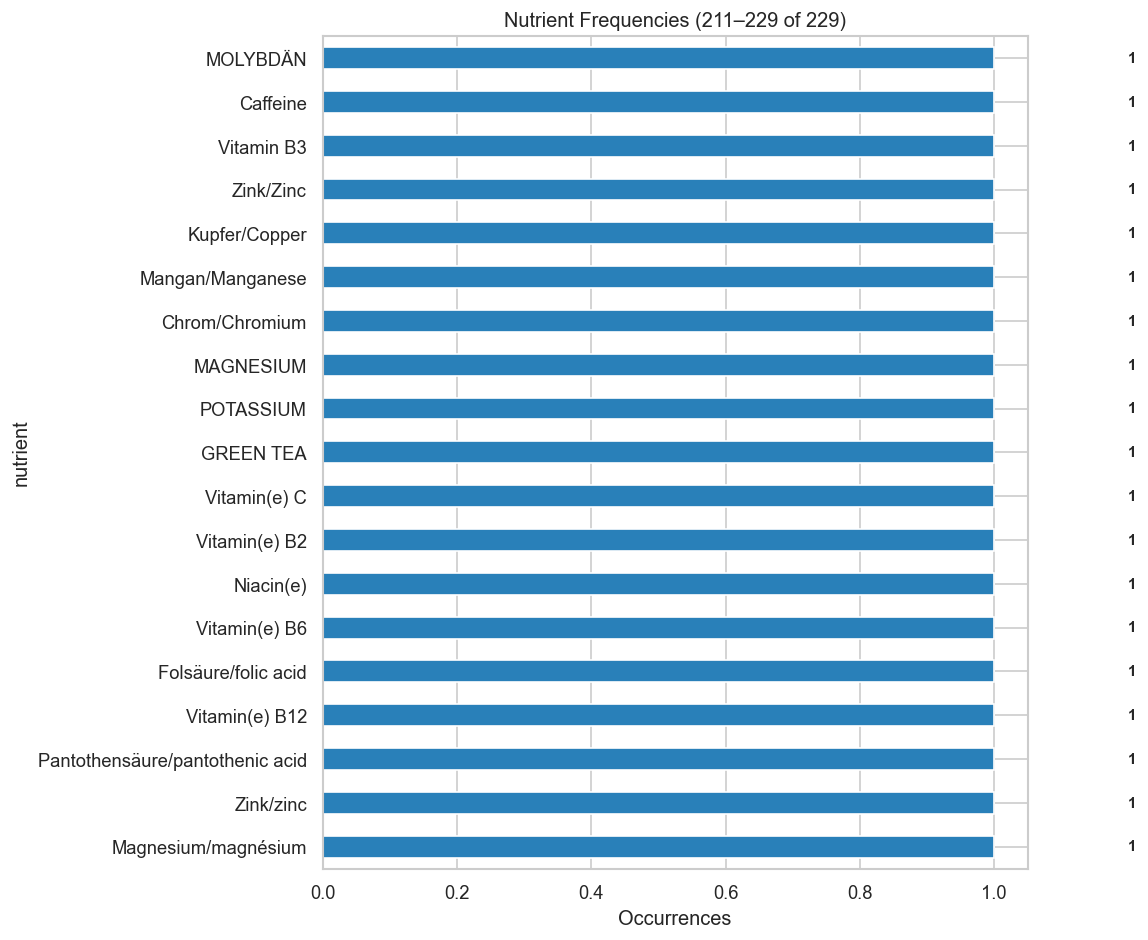

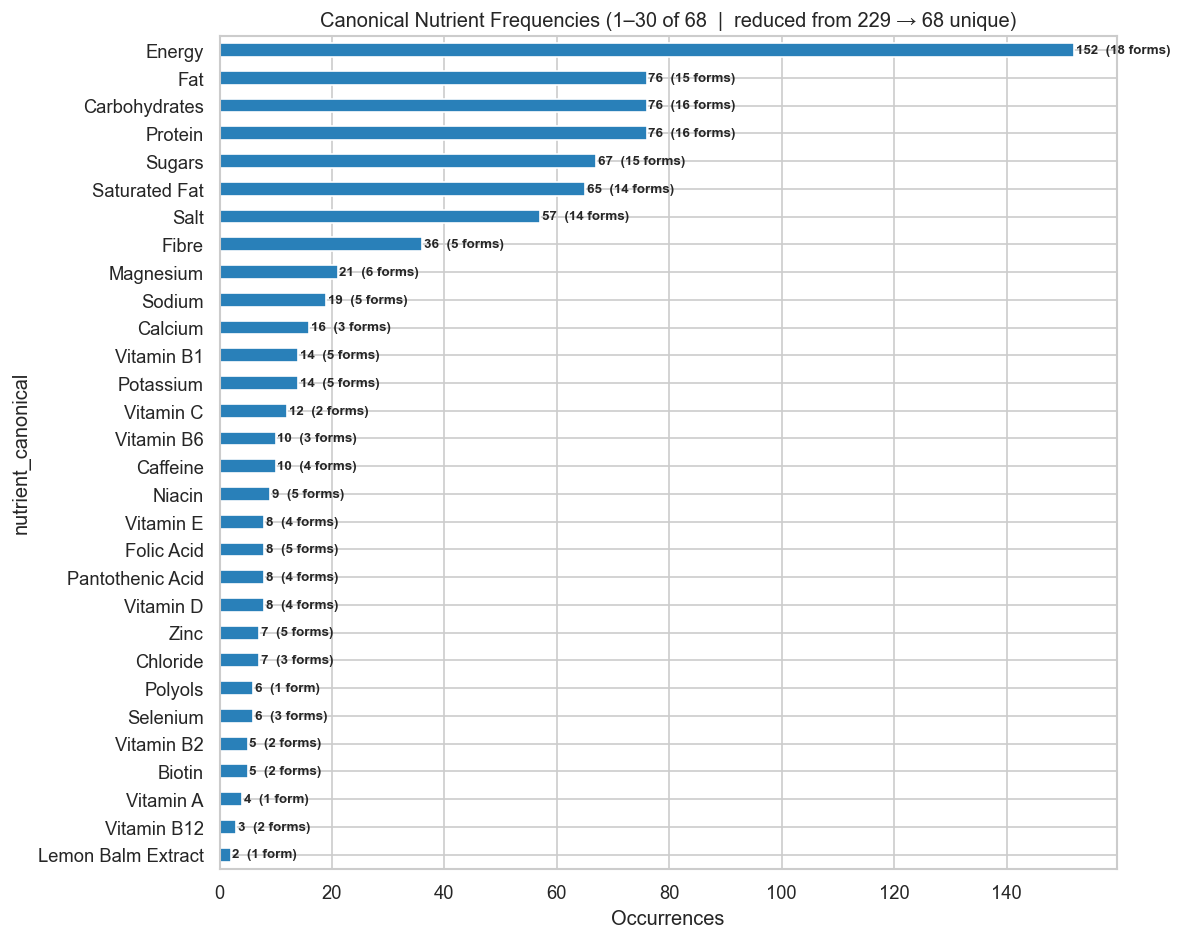

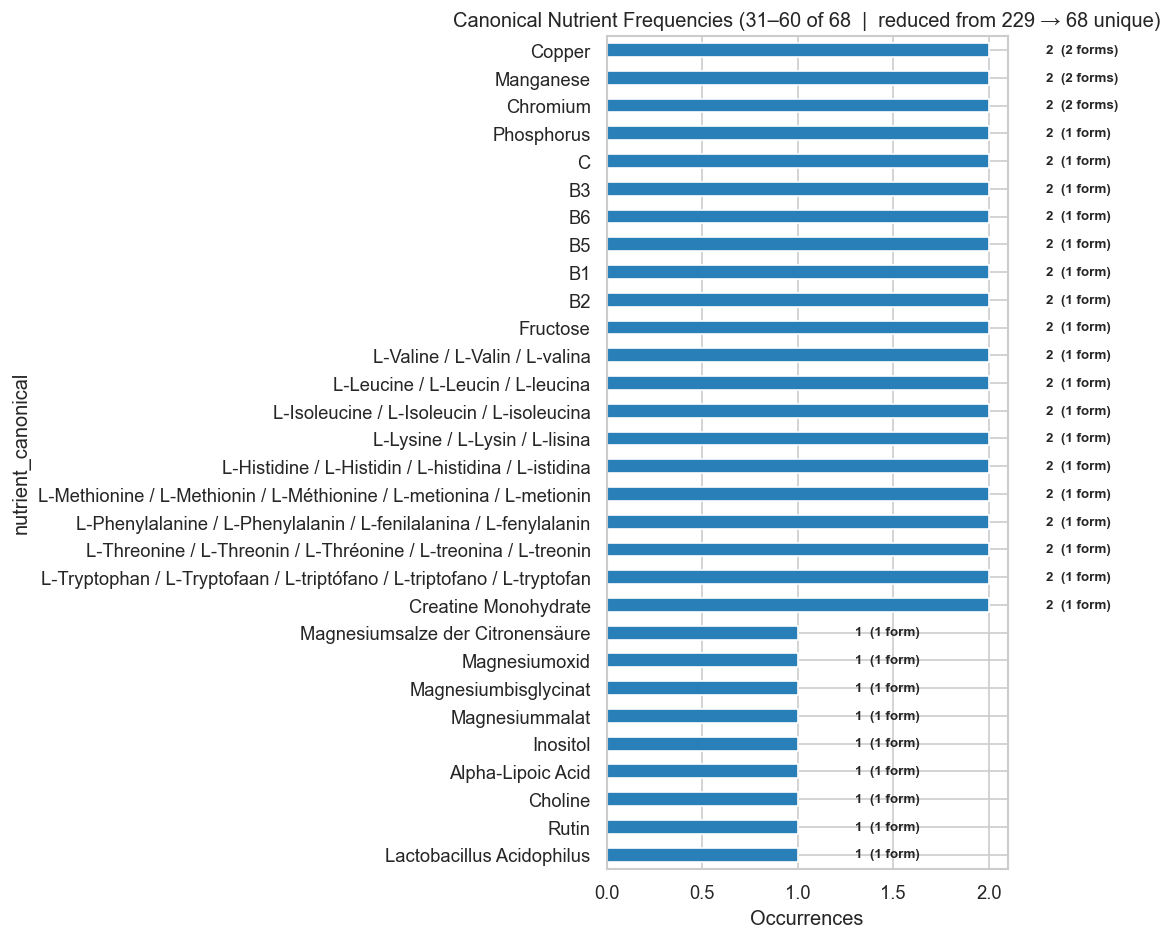

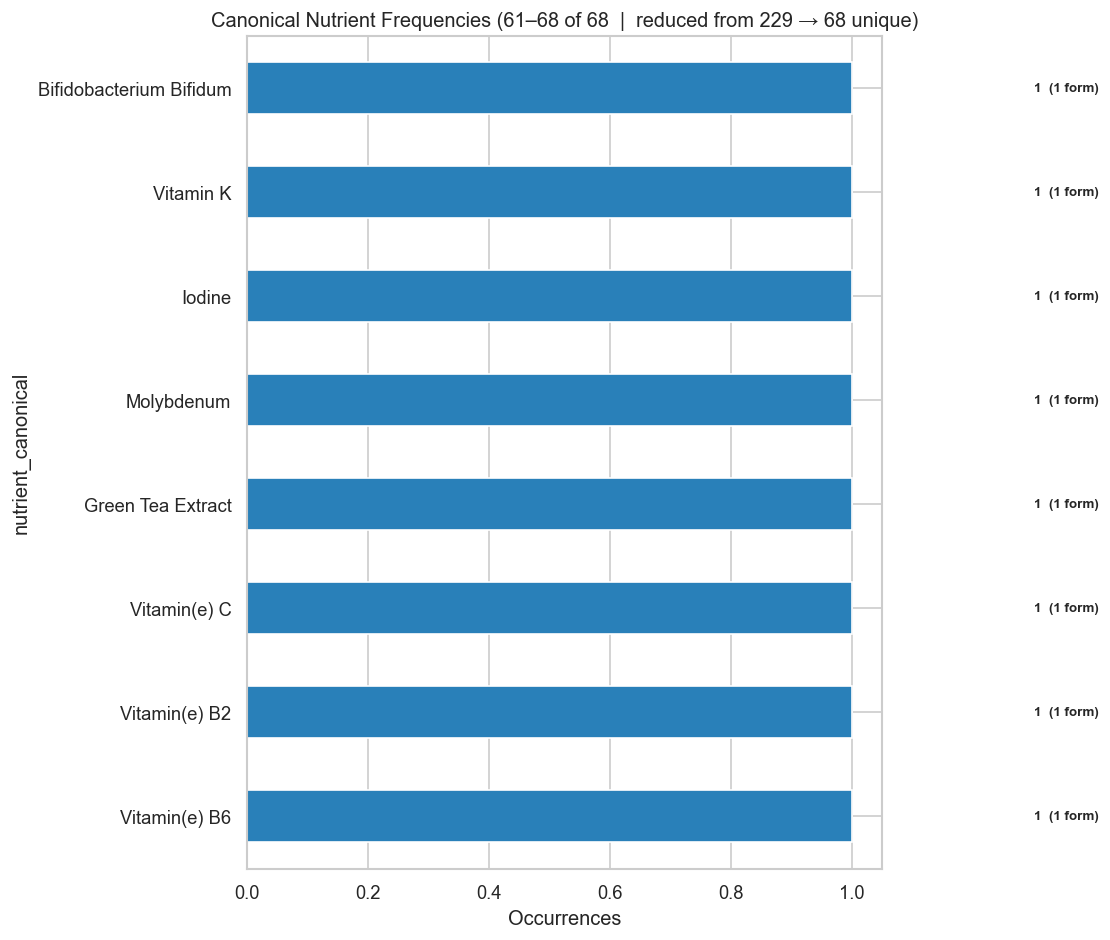

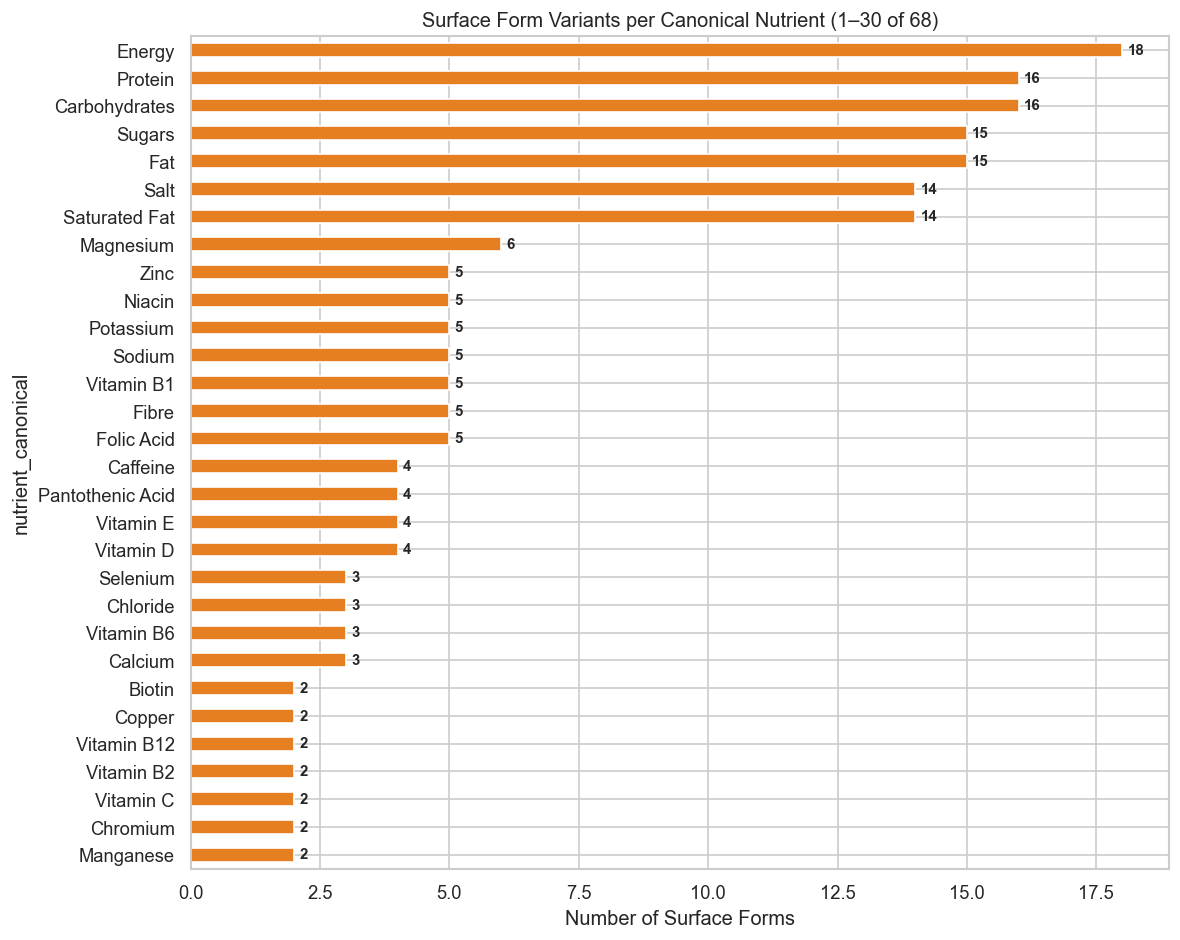

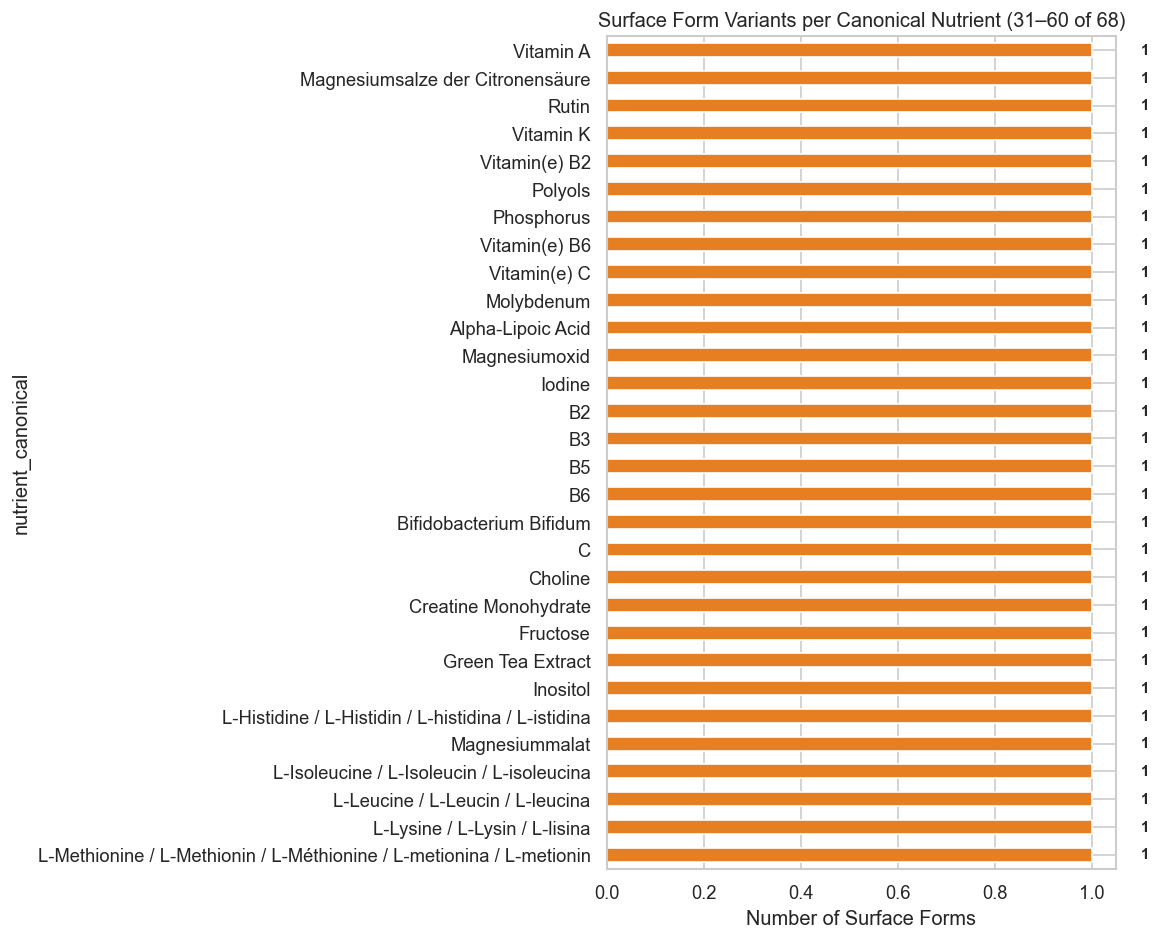

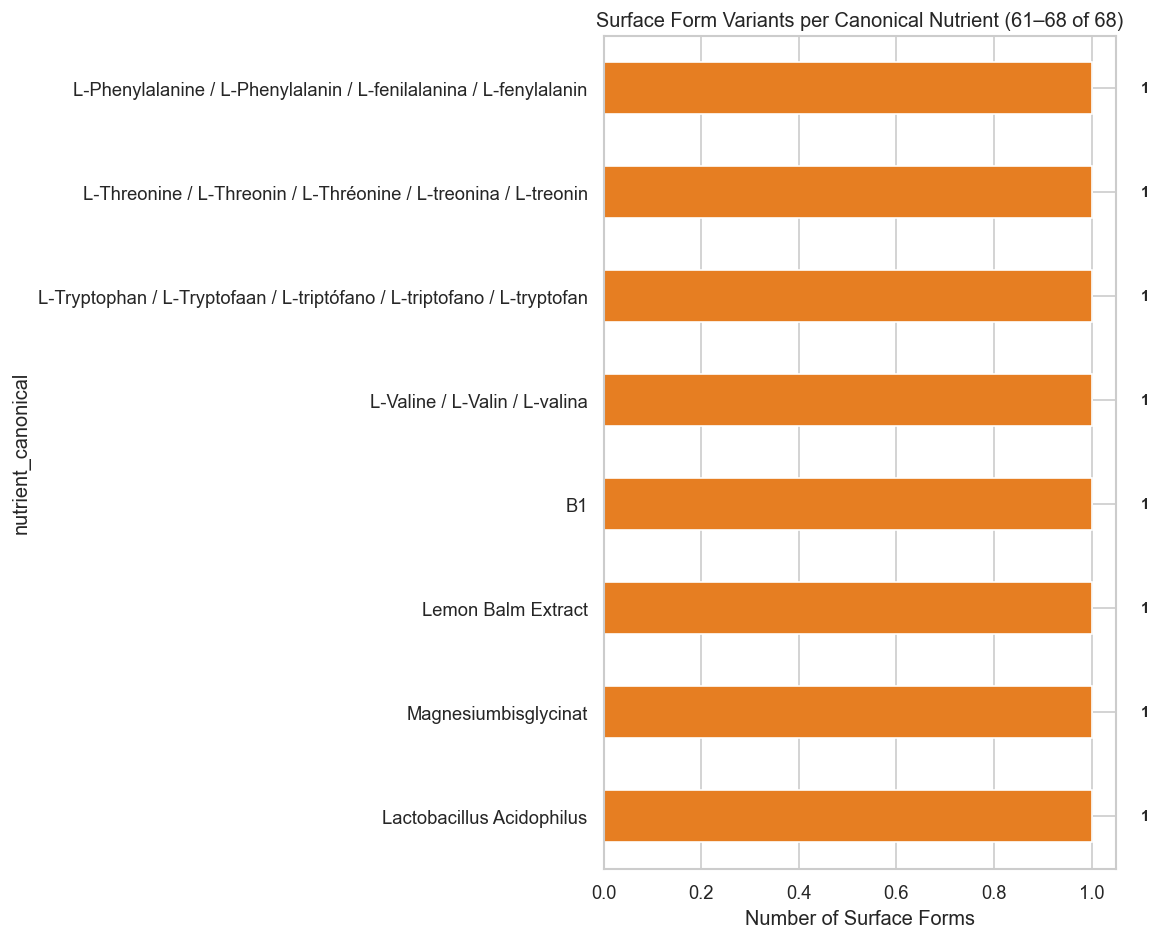

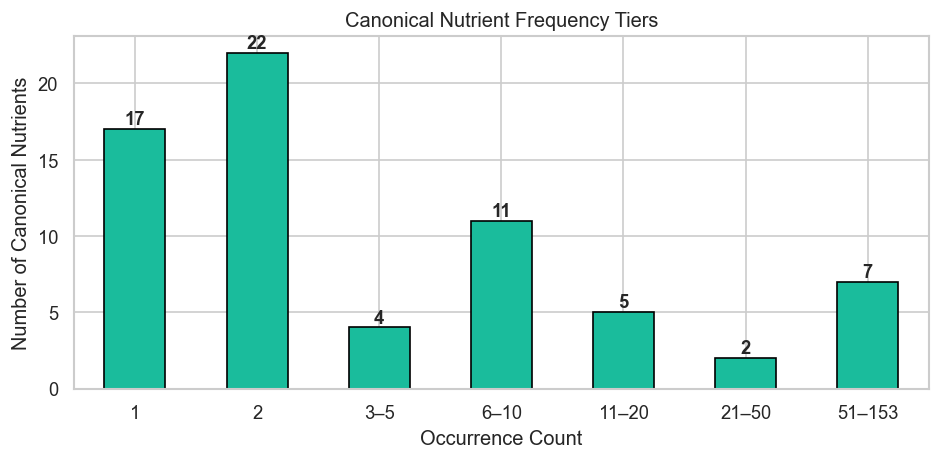

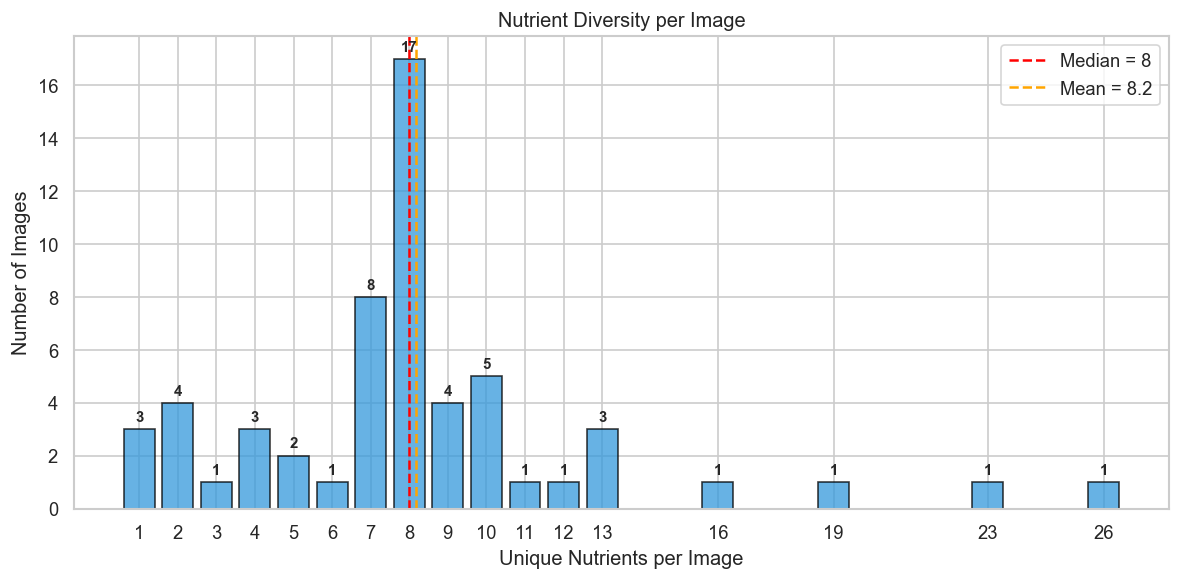

Surface forms: 229 → Canonical: 68
Reduction:     161 merged

Nutrients per image:
count    57.0
mean      8.2
std       4.7
min       1.0
25%       7.0
50%       8.0
75%       9.0
max      26.0


Top 10 most variant-rich nutrients:

  Energy (18 forms):
    • Energie
    • Brennwert
    • ENERGIE kJ
    • ENERGIE kcal
    • ENERGIE
    • Energie / Energia / Energie / Energi / Energia / Energi
    • Energie/energy kJ
    • Energie/energy kcal
    • Brennwert/Energy Value
    • Energie/ Energy/ Energie/ Énergie/ Wartość energetyczna/ Energetická hodnota/ Energia/ Energia/ Valor energético/ Energia
    • ENERGY
    • Energy
    • Energy | Energie
    • Brennwert ...... Energie
    • Energy / Energie / Energia / Énergie / Energia / Energijska vrednost
    • Energy / Energi(e/a) / Valor energético kJ (kcal)
    • Energie/energy/energia kJ (kcal)
    • Energie/energy kJ (kcal)

  Protein (16 forms):
    • Eiweiß
    • EIWEIẞ
    • Eiwitten / Proteiinit / Protéines / Protein / Białko / Prote

In [23]:
# ============================================================
# Nutrient Canonicalization — group surface forms into families
# ============================================================

def canonicalize(nutrient):
    text = nutrient.lower().strip().lstrip('- ').strip()

    for prefix in ['davon ', 'of which ', 'dont ', 'waarvan ', 'w tym ',
                    'z toho ', 'di cui ', 'de las cuales ', 'dos quais ',
                    'josta ', 'med andel ', 'varav ', 'od tega ']:
        if text.startswith(prefix):
            text = text[len(prefix):]

    sub_nutrient_markers = [
        'magnesiumoxid', 'magnesiumbisglycinat', 'magnesiummalat',
        'magnesiumsalze', 'magnesiumcitrat',
    ]
    for marker in sub_nutrient_markers:
        if marker in text:
            return nutrient.strip()

    if text.startswith('l-'):
        return nutrient.strip()

    sat_fat_keys = ['gesättigte fettsäuren', 'saturated fat', 'saturates',
                    'verzadigde vetzuren', 'mättat fett', 'nasycené',
                    'nasycone', 'saturi', 'gesättigte', 'saturadas',
                    'saturados', 'acidi grassi saturi']
    for k in sat_fat_keys:
        if k in text:
            return 'Saturated Fat'

    sugar_keys = ['zucker', 'sugar', 'sucres', 'zuccheri', 'suikers',
                  'azúcares', 'açúcares', 'socker', 'cukry', 'zuckerarten',
                  'sladkorji', 'sokereiden']
    for k in sugar_keys:
        if k in text:
            return 'Sugars'

    selenium_keys = ['selen', 'selenium']
    for k in selenium_keys:
        if k in text:
            return 'Selenium'

    if 'phospho' in text or 'phosph' in text:
        return 'Phosphorus'

    if 'fructose' in text:
        return 'Fructose'

    KEYWORD_ORDER = [
        (['brennwert', 'energie', 'energy', 'energijska', 'energia',
          'énergie', 'wartość energetyczna', 'energi'], 'Energy'),
        (['fett', 'fat', 'lipide', 'grassi', 'graisse', 'grasas',
          'maščobe', 'vetten', 'rasva', 'tłuszcz', 'tuky', 'lípidos',
          'matières grasses'], 'Fat'),
        (['kohlenhydrate', 'carbohydrate', 'carbohydrates', 'glucides',
          'carboidrati', 'koolhydraten', 'hiilihydraatit', 'węglowodany',
          'kolhydrater', 'sacharidy', 'hidratos de carbono',
          'karbohydrater'], 'Carbohydrates'),
        (['ballaststoffe', 'fibre', 'dietary fibre'], 'Fibre'),
        (['eiweiß', 'eiweiss', 'protein', 'protéines',
          'proteine', 'proteínas', 'eiwitten', 'proteiinit', 'białko',
          'bílkoviny', 'bielkoviny', 'beljakovine'], 'Protein'),
        (['salz', 'salt', 'sel', 'zout', 'suola', 'sól', 'sůl', 'sol'], 'Salt'),
        (['natrium', 'sodium'], 'Sodium'),
        (['magnesium', 'magnésium', 'magnesio', 'magnezij', 'magnézium'], 'Magnesium'),
        (['calcium', 'kalzium', 'calcio', 'kalcij'], 'Calcium'),
        (['kalium', 'potassium', 'potasio', 'kalij'], 'Potassium'),
        (['zink', 'zinc'], 'Zinc'),
        (['kupfer', 'copper'], 'Copper'),
        (['mangan', 'manganese'], 'Manganese'),
        (['chrom', 'chromium'], 'Chromium'),
        (['chlorid', 'chloride', 'chlorure'], 'Chloride'),
        (['molybdän'], 'Molybdenum'),
        (['jod'], 'Iodine'),
        (['vitamin a'], 'Vitamin A'),
        (['vitamin c'], 'Vitamin C'),
        (['vitamin d', 'colecalciferol'], 'Vitamin D'),
        (['vitamin e'], 'Vitamin E'),
        (['vitamin k'], 'Vitamin K'),
        (['vitamin b1', 'thiamin'], 'Vitamin B1'),
        (['vitamin b2', 'riboflavin'], 'Vitamin B2'),
        (['vitamin b3', 'niacin'], 'Niacin'),
        (['vitamin b5', 'pantothensäure', 'pantothenic acid'], 'Pantothenic Acid'),
        (['vitamin b6'], 'Vitamin B6'),
        (['vitamin b12', 'b12'], 'Vitamin B12'),
        (['biotin'], 'Biotin'),
        (['folsäure', 'folic acid'], 'Folic Acid'),
        (['cholin'], 'Choline'),
        (['koffein', 'caffeine'], 'Caffeine'),
        (['creatine monohydrate'], 'Creatine Monohydrate'),
        (['inositol'], 'Inositol'),
        (['rutin'], 'Rutin'),
        (['alpha-liponsäure'], 'Alpha-Lipoic Acid'),
        (['mehrwertige alkohole', 'polyol'], 'Polyols'),
        (['green tea'], 'Green Tea Extract'),
        (['melissen'], 'Lemon Balm Extract'),
        (['tryptophan'], 'L-Tryptophan'),
        (['bifidobacterium'], 'Bifidobacterium Bifidum'),
        (['lactobacillus'], 'Lactobacillus Acidophilus'),
    ]

    for keywords, canonical in KEYWORD_ORDER:
        for kw in keywords:
            if kw in text:
                return canonical

    return nutrient.strip()

gt['nutrient_canonical'] = gt['nutrient'].apply(canonicalize)

# ============================================================
# PLOT 1: Paginated nutrient frequency (all surface forms)
# ============================================================
nut_counts = gt['nutrient'].value_counts()
WINDOW = 30

for start in range(0, len(nut_counts), WINDOW):
    chunk = nut_counts.iloc[start:start + WINDOW]
    fig, ax = plt.subplots(figsize=(10, 8))
    chunk.plot(kind='barh', ax=ax, color='#2980b9')
    ax.set_xlabel("Occurrences")
    ax.set_title(f"Nutrient Frequencies ({start+1}–{start+len(chunk)} of {len(nut_counts)})")
    ax.invert_yaxis()
    for i, val in enumerate(chunk.values):
        ax.text(val + 0.2, i, str(val), va='center', fontweight='bold', fontsize=9)
    plt.tight_layout()
    plt.savefig(f"gt_04a_nutrient_page{start//WINDOW + 1}.png", bbox_inches='tight')
    plt.show()

## ============================================================
# PLOT 2: Canonical nutrient frequency with surface form count
# ============================================================
canon_counts = gt['nutrient_canonical'].value_counts()
variant_counts = gt.groupby('nutrient_canonical')['nutrient'].nunique()

WINDOW = 30
for start in range(0, len(canon_counts), WINDOW):
    chunk = canon_counts.iloc[start:start + WINDOW]
    fig, ax = plt.subplots(figsize=(10, 8))
    chunk.plot(kind='barh', ax=ax, color='#2980b9')
    ax.set_xlabel("Occurrences")
    ax.set_title(f"Canonical Nutrient Frequencies ({start+1}–{start+len(chunk)} of {len(canon_counts)}  |  "
                 f"reduced from {gt['nutrient'].nunique()} → {gt['nutrient_canonical'].nunique()} unique)")
    ax.invert_yaxis()
    for i, (name, val) in enumerate(chunk.items()):
        n_forms = variant_counts.get(name, 1)
        label = f"{val}  ({n_forms} form{'s' if n_forms > 1 else ''})"
        ax.text(val + 0.3, i, label, va='center', fontweight='bold', fontsize=8)
    plt.tight_layout()
    plt.savefig(f"gt_04d_nutrient_canonical_page{start//WINDOW + 1}.png", bbox_inches='tight')
    plt.show()

# ============================================================
# PLOT 3: Surface form variants per canonical nutrient
# ============================================================
variants_per_canon = gt.groupby('nutrient_canonical')['nutrient'].nunique().sort_values(ascending=False)

WINDOW2 = 30
for start in range(0, len(variants_per_canon), WINDOW2):
    chunk = variants_per_canon.iloc[start:start + WINDOW2]
    fig, ax = plt.subplots(figsize=(10, 8))
    chunk.plot(kind='barh', ax=ax, color='#e67e22')
    ax.set_xlabel("Number of Surface Forms")
    ax.set_title(f"Surface Form Variants per Canonical Nutrient ({start+1}–{start+len(chunk)} of {len(variants_per_canon)})")
    ax.invert_yaxis()
    for i, val in enumerate(chunk.values):
        ax.text(val + 0.1, i, str(val), va='center', fontweight='bold', fontsize=9)
    plt.tight_layout()
    plt.savefig(f"gt_04e_surface_variants_page{start//WINDOW2 + 1}.png", bbox_inches='tight')
    plt.show()

# ============================================================
# PLOT 4: Frequency tiers (canonical)
# ============================================================
max_count = canon_counts.max()
bin_edges = sorted(set([0, 1, 2, 5, 10, 20, 50, max(51, max_count + 1)]))
bin_labels = []
for i in range(len(bin_edges) - 1):
    lo, hi = bin_edges[i], bin_edges[i + 1]
    if hi - lo == 1:
        bin_labels.append(str(hi))
    else:
        bin_labels.append(f"{lo+1}–{hi}")

freq_tiers = pd.cut(canon_counts, bins=bin_edges, labels=bin_labels, right=True)
tier_counts = freq_tiers.value_counts().reindex(bin_labels).fillna(0).astype(int)
tier_counts = tier_counts[tier_counts > 0]

fig, ax = plt.subplots(figsize=(8, 4))
tier_counts.plot(kind='bar', ax=ax, color='#1abc9c', edgecolor='black')
ax.set_xlabel("Occurrence Count")
ax.set_ylabel("Number of Canonical Nutrients")
ax.set_title("Canonical Nutrient Frequency Tiers")
plt.xticks(rotation=0)
for i, val in enumerate(tier_counts.values):
    ax.text(i, val + 0.3, str(val), ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig("gt_04f_canonical_frequency_tiers.png", bbox_inches='tight')
plt.show()

# ============================================================
# PLOT 5: Unique nutrients per image
# ============================================================
nuts_per_img = gt.groupby('image_id')['nutrient'].nunique().reset_index(name='n_unique')

fig, ax = plt.subplots(figsize=(10, 5))
counts = nuts_per_img['n_unique'].value_counts().sort_index()
ax.bar(counts.index, counts.values, color='#3498db', edgecolor='black', alpha=0.75)
ax.axvline(nuts_per_img['n_unique'].median(), color='red', ls='--',
           label=f"Median = {nuts_per_img['n_unique'].median():.0f}")
ax.axvline(nuts_per_img['n_unique'].mean(), color='orange', ls='--',
           label=f"Mean = {nuts_per_img['n_unique'].mean():.1f}")
ax.set_xlabel("Unique Nutrients per Image")
ax.set_ylabel("Number of Images")
ax.set_title("Nutrient Diversity per Image")
ax.set_xticks(counts.index)
for i, (x, val) in enumerate(zip(counts.index, counts.values)):
    ax.text(x, val + 0.3, str(val), ha='center', fontweight='bold', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig("gt_04g_nutrients_per_image.png", bbox_inches='tight')
plt.show()

# ============================================================
# Summary + detailed tier printout
# ============================================================
print(f"Surface forms: {gt['nutrient'].nunique()} → Canonical: {gt['nutrient_canonical'].nunique()}")
print(f"Reduction:     {gt['nutrient'].nunique() - gt['nutrient_canonical'].nunique()} merged")

print(f"\nNutrients per image:")
print(nuts_per_img['n_unique'].describe().round(1).to_string())

print(f"\n\nTop 10 most variant-rich nutrients:")
for canon, n_variants in variants_per_canon.head(10).items():
    forms = gt[gt['nutrient_canonical'] == canon]['nutrient'].unique()
    print(f"\n  {canon} ({n_variants} forms):")
    for f in forms:
        print(f"    • {f}")

In [37]:
# ============================================================
# Quantity Value Analysis — Text Only
# ============================================================

valid_qty = gt['qty_numeric'].dropna()
non_numeric = gt[gt['qty_numeric'].isna()]
zeros = gt[gt['qty_numeric'] == 0]
extremes = gt[gt['qty_numeric'] > 1000]

print("=== Quantity Overview ===")
print(f"Total tuples:       {len(gt)}")
print(f"Numeric quantities: {len(valid_qty)} ({100*len(valid_qty)/len(gt):.1f}%)")
print(f"Scientific notation: {len(non_numeric)} (3.6 x 10^8 — probiotic CFU counts)")
print(f"Zero values:        {len(zeros)}")
print(f"Extreme (>1000):    {len(extremes)}")
# ── Decimal precision ──
qty_strs = gt.loc[gt['qty_numeric'].notna(), 'quantity'].astype(str).str.replace(',', '.')
decimal_places = qty_strs.apply(
    lambda x: len(x.strip().split('.')[1]) if '.' in x.strip() else 0
)
dec_counts = decimal_places.value_counts().sort_index()
print(f"\n=== Decimal Precision ===")
for dp, count in dec_counts.items():
    print(f"  {dp} decimal places: {count} tuples ({100*count/len(valid_qty):.1f}%)")

# ── Per-unit breakdown with quantity bins ──
print(f"\n{'='*70}")
print(f"  QUANTITY DISTRIBUTION BY UNIT")
print(f"{'='*70}")

for unit in gt['unit'].value_counts().index:
    subset = gt[(gt['unit'] == unit) & gt['qty_numeric'].notna()]['qty_numeric']
    if len(subset) == 0:
        continue
    unit_label = unit if unit.strip() else '(empty)'
    
    print(f"\n  {unit_label} (n={len(subset)})")
    print(f"  {'-'*50}")
    print(f"    Range:  {subset.min():.4g} – {subset.max():.4g}")
    print(f"    Mean:   {subset.mean():.4g}  |  Median: {subset.median():.4g}  |  Std: {subset.std():.4g}")
    
    # Dynamic bins based on unit type
    if unit.strip().lower() in ['g']:
        bins = [(0, 0, '= 0'), (0.01, 1, '0.01 – 1'), (1.01, 10, '1.01 – 10'),
                (10.01, 50, '10.01 – 50'), (50.01, 100, '50.01 – 100')]
    elif unit.strip().lower() in ['mg']:
        bins = [(0, 0, '= 0'), (0.01, 1, '0.01 – 1'), (1.01, 10, '1.01 – 10'),
                (10.01, 100, '10.01 – 100'), (100.01, 500, '100.01 – 500'),
                (500.01, 5000, '500.01 – 5000')]
    elif unit.strip().lower() in ['µg']:
        bins = [(0, 0, '= 0'), (0.01, 10, '0.01 – 10'), (10.01, 100, '10.01 – 100'),
                (100.01, 500, '100.01 – 500'), (500.01, 11000, '500.01+')]
    elif unit.strip().lower() in ['kcal']:
        bins = [(0, 0, '= 0'), (0.01, 100, '0.01 – 100'), (100.01, 200, '100.01 – 200'),
                (200.01, 300, '200.01 – 300'), (300.01, 500, '300.01 – 500')]
    elif unit.strip().lower() in ['kj']:
        bins = [(0, 0, '= 0'), (0.01, 500, '0.01 – 500'), (500.01, 1000, '500.01 – 1000'),
                (1000.01, 2000, '1000.01 – 2000')]
    else:
        bins = [(subset.min(), subset.max(), f'{subset.min():.4g} – {subset.max():.4g}')]
    
    print(f"    Distribution:")
    for lo, hi, label in bins:
        if lo == hi == 0:
            count = (subset == 0).sum()
        else:
            count = ((subset >= lo) & (subset <= hi)).sum()
        if count > 0:
            bar = '█' * min(count, 40)
            print(f"      {label:>20s}: {count:>4d} ({100*count/len(subset):5.1f}%)  {bar}")
    
    # Show which nutrients use this unit
    nutrients = gt[(gt['unit'] == unit)]['nutrient_canonical'].value_counts()
    print(f"    Used by: {', '.join([f'{n} ({c})' for n, c in nutrients.head(8).items()])}")
    if len(nutrients) > 8:
        print(f"             ... and {len(nutrients) - 8} more")

# ── Non-numeric details ──
if len(non_numeric) > 0:
    print(f"\n{'='*70}")
    print(f"  NON-NUMERIC QUANTITIES ({len(non_numeric)})")
    print(f"{'='*70}")
    for _, row in non_numeric.iterrows():
        print(f"  {row['image_id']}: {row['nutrient']} = '{row['quantity']}' {row['unit']}")

# ── Zero value details ──
print(f"\n{'='*70}")
print(f"  ZERO QUANTITIES ({len(zeros)})")
print(f"{'='*70}")
zero_nutrients = zeros['nutrient_canonical'].value_counts()
print(f"  By nutrient:")
for n, c in zero_nutrients.items():
    print(f"    {n}: {c}")
zero_images = zeros['image_id'].value_counts()
print(f"\n  By image ({len(zero_images)} images have zeros):")
for img, c in zero_images.items():
    print(f"    {img}: {c} zero tuples")

# ── Extreme value details ──
if len(extremes) > 0:
    print(f"\n{'='*70}")
    print(f"  EXTREME QUANTITIES >1000 ({len(extremes)})")
    print(f"{'='*70}")
    for _, row in extremes.iterrows():
        print(f"  {row['image_id']}: {row['nutrient']} = {row['quantity']} {row['unit']} [{row['context_base']}]")

# ── Per canonical nutrient breakdown (top 20) ──
print(f"\n{'='*70}")
print(f"  QUANTITY RANGE BY CANONICAL NUTRIENT (Top 20)")
print(f"{'='*70}")
top_canon = gt['nutrient_canonical'].value_counts().head(20).index

if len(non_numeric) > 0:
        print(f"\n{'='*70}")
        print(f"  SCIENTIFIC NOTATION QUANTITIES ({len(non_numeric)})")
        print(f"{'='*70}")
        for _, row in non_numeric.iterrows():
            print(f"  {row['image_id']}: {row['nutrient']} = {row['quantity']} {row['unit']} [{row['context']}]")
        print(f"  Note: 3.6 x 10^8 = 360,000,000 colony-forming units (KBE)")

=== Quantity Overview ===
Total tuples:       866
Numeric quantities: 864 (99.8%)
Scientific notation: 2 (3.6 x 10^8 — probiotic CFU counts)
Zero values:        86
Extreme (>1000):    43

=== Decimal Precision ===
  0 decimal places: 480 tuples (55.6%)
  1 decimal places: 317 tuples (36.7%)
  2 decimal places: 64 tuples (7.4%)
  3 decimal places: 3 tuples (0.3%)

  QUANTITY DISTRIBUTION BY UNIT

  g (n=481)
  --------------------------------------------------
    Range:  0 – 100
    Mean:   11.72  |  Median: 2.2  |  Std: 21.18
    Distribution:
                       = 0:   82 ( 17.0%)  ████████████████████████████████████████
                  0.01 – 1:  117 ( 24.3%)  ████████████████████████████████████████
                 1.01 – 10:  160 ( 33.3%)  ████████████████████████████████████████
                10.01 – 50:   84 ( 17.5%)  ████████████████████████████████████████
               50.01 – 100:   38 (  7.9%)  ██████████████████████████████████████
    Used by: Fat (76), Carbohyd

In [36]:
# ============================================================
# NRV  Coverage — Text Only
# ============================================================

gt['has_nrv'] = gt['nrv_percent'].astype(str).str.strip().apply(
    lambda x: x not in ('', 'nan', 'None', 'NaN')
)
gt['has_serving'] = gt['serving_size'].astype(str).str.strip().apply(
    lambda x: x not in ('', 'nan', 'None', 'NaN')
)
gt['nrv_numeric'] = pd.to_numeric(
    gt['nrv_percent'].astype(str).str.replace(',', '.').str.strip('<%~ '),
    errors='coerce'
)

nrv_yes = gt['has_nrv'].sum()
srv_yes = gt['has_serving'].sum()
valid_nrv = gt['nrv_numeric'].dropna()

print("=== NRV Coverage ===")
print(f"  Tuples with NRV %:       {nrv_yes} / {len(gt)} ({100*nrv_yes/len(gt):.1f}%)")
print(f"  Tuples without NRV %:    {len(gt) - nrv_yes} / {len(gt)} ({100*(len(gt)-nrv_yes)/len(gt):.1f}%)")

print(f"\n=== NRV % Value Statistics ===")
print(f"  Count:   {len(valid_nrv)}")
print(f"  Mean:    {valid_nrv.mean():.1f}%")
print(f"  Median:  {valid_nrv.median():.1f}%")
print(f"  Std:     {valid_nrv.std():.1f}%")
print(f"  Min:     {valid_nrv.min():.1f}%")
print(f"  Max:     {valid_nrv.max():.1f}%")

# ── NRV distribution bins ──
nrv_bins = [(0, 10, '0–10%'), (10.01, 25, '10–25%'), (25.01, 50, '25–50%'),
            (50.01, 100, '50–100%'), (100.01, 200, '100–200%'),
            (200.01, 500, '200–500%'), (500.01, 3000, '500%+')]

print(f"\n=== NRV % Distribution ===")
for lo, hi, label in nrv_bins:
    count = ((valid_nrv >= lo) & (valid_nrv <= hi)).sum()
    if count > 0:
        bar = '█' * min(count, 40)
        print(f"  {label:>12s}: {count:>4d} ({100*count/len(valid_nrv):5.1f}%)  {bar}")

# ── NRV by context ──
print(f"\n=== NRV Coverage by Context ===")
for ctx in gt['context_base'].value_counts().index:
    ctx_data = gt[gt['context_base'] == ctx]
    ctx_nrv = ctx_data['has_nrv'].sum()
    print(f"  {ctx}: {ctx_nrv} / {len(ctx_data)} ({100*ctx_nrv/len(ctx_data):.1f}%)")

# ── NRV by canonical nutrient (only those with NRV) ──
print(f"\n=== NRV Coverage by Canonical Nutrient ===")
print(f"  {'Nutrient':<25s} {'Has NRV':>8s} {'Total':>6s} {'Coverage':>9s} {'Mean NRV':>9s}")
print(f"  {'-'*60}")

nrv_by_nut = gt.groupby('nutrient_canonical').agg(
    total=('has_nrv', 'count'),
    has_nrv=('has_nrv', 'sum'),
    mean_nrv=('nrv_numeric', 'mean')
).sort_values('has_nrv', ascending=False)

for name, row in nrv_by_nut.iterrows():
    if row['has_nrv'] > 0:
        mean_str = f"{row['mean_nrv']:.1f}%" if pd.notna(row['mean_nrv']) else "–"
        print(f"  {name:<25s} {int(row['has_nrv']):>8d} {int(row['total']):>6d} "
              f"{100*row['has_nrv']/row['total']:>8.1f}% {mean_str:>9s}")

# ── NRV > 100% details ──
oover100 = gt[gt['nrv_numeric'] > 100].sort_values('nrv_numeric', ascending=False)
print(f"\n=== Tuples with NRV > 100% ({len(over100)} tuples) ===")
for _, row in over100.iterrows():
    print(f"  {row['image_id']:>12s}  {row['nutrient_canonical']:<20s}  "
          f"{row['quantity']:>8s} {row['unit']:<8s}  NRV={row['nrv_percent']}%  [{row['context_base']}]")




=== NRV Coverage ===
  Tuples with NRV %:       175 / 866 (20.2%)
  Tuples without NRV %:    691 / 866 (79.8%)

=== NRV % Value Statistics ===
  Count:   175
  Mean:    151.7%
  Median:  42.0%
  Std:     300.3%
  Min:     1.0%
  Max:     2240.0%

=== NRV % Distribution ===
         0–10%:   47 ( 26.9%)  ████████████████████████████████████████
        10–25%:   34 ( 19.4%)  ██████████████████████████████████
        25–50%:   18 ( 10.3%)  ██████████████████
       50–100%:   39 ( 22.3%)  ███████████████████████████████████████
      100–200%:    8 (  4.6%)  ████████
      200–500%:    9 (  5.1%)  █████████
         500%+:   20 ( 11.4%)  ████████████████████

=== NRV Coverage by Context ===
  per_100g: 47 / 381 (12.3%)
  per_serving: 67 / 323 (20.7%)
  per_daily_dose: 61 / 130 (46.9%)
  per_100ml: 0 / 32 (0.0%)

=== NRV Coverage by Canonical Nutrient ===
  Nutrient                   Has NRV  Total  Coverage  Mean NRV
  ------------------------------------------------------------
  Magne

In [38]:
# ============================================================
# Multilingual Complexity Analysis 
# ============================================================

gt['n_segments'] = gt['nutrient'].apply(lambda x: len([s for s in re.split(r'[/|]', x) if s.strip()]))
gt['name_length'] = gt['nutrient'].str.len()

mono  = (gt['n_segments'] == 1).sum()
bi    = (gt['n_segments'] == 2).sum()
multi = (gt['n_segments'] >= 3).sum()

print("=== Multilingual Complexity Summary ===")
print(f"  Monolingual tuples (1 segment):    {mono} ({100*mono/len(gt):.1f}%)")
print(f"  Bilingual tuples (2 segments):     {bi} ({100*bi/len(gt):.1f}%)")
print(f"  Multilingual tuples (3+ segments): {multi} ({100*multi/len(gt):.1f}%)")
print(f"\n  Avg segments per nutrient name:    {gt['n_segments'].mean():.2f}")
print(f"  Max segments in dataset:           {gt['n_segments'].max()}")
print(f"  Avg nutrient name length:          {gt['name_length'].mean():.1f} chars")
print(f"  Max nutrient name length:          {gt['name_length'].max()} chars")

# ── Segment count distribution ──
seg_counts = gt['n_segments'].value_counts().sort_index()
print(f"\n=== Segment Count Distribution ===")
for seg, count in seg_counts.items():
    bar = '█' * min(count, 40)
    print(f"  {seg:>2d} segments: {count:>4d} ({100*count/len(gt):5.1f}%)  {bar}")

# ── Image-level tiers ──
img_complexity = gt.groupby('image_id').agg(
    total_tuples=('n_segments', 'count'),
    avg_segments=('n_segments', 'mean'),
    max_segments=('n_segments', 'max'),
).sort_values('avg_segments', ascending=False)

mono_imgs = (img_complexity['avg_segments'] == 1).sum()
mixed_imgs = ((img_complexity['avg_segments'] > 1) & (img_complexity['avg_segments'] < 3)).sum()
high_imgs = (img_complexity['avg_segments'] >= 3).sum()

print(f"\n=== Image-Level Tiers ===")
print(f"  Monolingual images (avg seg = 1):   {mono_imgs} ({100*mono_imgs/len(img_complexity):.1f}%)")
print(f"  Mixed images (1 < avg < 3):         {mixed_imgs} ({100*mixed_imgs/len(img_complexity):.1f}%)")
print(f"  Highly multilingual (avg seg >= 3):  {high_imgs} ({100*high_imgs/len(img_complexity):.1f}%)")

# ── Highly multilingual images detail ──
high_multi = img_complexity[img_complexity['avg_segments'] >= 3]
if len(high_multi) > 0:
    print(f"\n=== Highly Multilingual Images (avg >= 3 segments) ===")
    for img, row in high_multi.iterrows():
        print(f"  {img}: {row['total_tuples']} tuples, avg {row['avg_segments']:.1f} seg, max {row['max_segments']} seg")

# ── Longest nutrient names ──
longest = gt.nlargest(10, 'name_length')
print(f"\n=== Top 10 Longest Nutrient Names ===")
for _, row in longest.iterrows():
    print(f"  {row['image_id']:>12s}  ({row['name_length']:>3d} chars, {row['n_segments']} seg):")
    print(f"    {row['nutrient'][:120]}{'...' if len(row['nutrient']) > 120 else ''}")

# ── Multilingual complexity by canonical nutrient ──
nut_complexity = gt.groupby('nutrient_canonical').agg(
    total=('n_segments', 'count'),
    avg_seg=('n_segments', 'mean'),
    max_seg=('n_segments', 'max')
).sort_values('avg_seg', ascending=False)

multi_nuts = nut_complexity[nut_complexity['max_seg'] >= 2]
print(f"\n=== Canonical Nutrients with Multilingual Variants ({len(multi_nuts)}) ===")
print(f"  {'Nutrient':<25s} {'Total':>6s} {'Avg Seg':>8s} {'Max Seg':>8s}")
print(f"  {'-'*50}")
for name, row in multi_nuts.iterrows():
    print(f"  {name:<25s} {int(row['total']):>6d} {row['avg_seg']:>8.1f} {int(row['max_seg']):>8d}")

=== Multilingual Complexity Summary ===
  Monolingual tuples (1 segment):    539 (62.2%)
  Bilingual tuples (2 segments):     159 (18.4%)
  Multilingual tuples (3+ segments): 168 (19.4%)

  Avg segments per nutrient name:    2.03
  Max segments in dataset:           10
  Avg nutrient name length:          23.4 chars
  Max nutrient name length:          277 chars

=== Segment Count Distribution ===
   1 segments:  539 ( 62.2%)  ████████████████████████████████████████
   2 segments:  159 ( 18.4%)  ████████████████████████████████████████
   3 segments:   28 (  3.2%)  ████████████████████████████
   4 segments:   44 (  5.1%)  ████████████████████████████████████████
   5 segments:   10 (  1.2%)  ██████████
   6 segments:   62 (  7.2%)  ████████████████████████████████████████
   7 segments:    4 (  0.5%)  ████
   8 segments:    4 (  0.5%)  ████
  10 segments:   16 (  1.8%)  ████████████████

=== Image-Level Tiers ===
  Monolingual images (avg seg = 1):   39 (68.4%)
  Mixed images (1 < av

In [40]:
ctx_per_img = gt.groupby('image_id').agg(
    n_contexts=('context_base', 'nunique')
).reset_index()

multi_tuples = gt[gt['image_id'].isin(ctx_per_img[ctx_per_img['n_contexts'] >= 2]['image_id'])].shape[0]

img_complexity = gt.groupby('image_id')['n_segments'].mean()
mono_imgs = (img_complexity == 1).sum()
high_imgs = (img_complexity >= 3).sum()
# ============================================================
# GT Dataset — Consolidated Summary
# ============================================================

tuples_per_img = gt.groupby('image_id').size()

print(f"{'='*70}")
print(f"  GT DATASET — CONSOLIDATED SUMMARY")
print(f"{'='*70}")

print(f"\n── SCALE ──")
print(f"  Total images:                      {gt['image_id'].nunique()}")
print(f"  Total GT tuples:                   {len(gt)}")
print(f"  Tuples/image (mean ± SD):          {tuples_per_img.mean():.1f} ± {tuples_per_img.std():.1f}")
print(f"  Tuples/image (median):             {tuples_per_img.median():.0f}")
print(f"  Tuples/image (range):              {tuples_per_img.min()} – {tuples_per_img.max()}")

print(f"\n── NUTRIENTS ──")
print(f"  Unique surface forms:              {gt['nutrient'].nunique()}")
print(f"  Canonical nutrients:               {gt['nutrient_canonical'].nunique()}")
print(f"  Surface forms merged:              {gt['nutrient'].nunique() - gt['nutrient_canonical'].nunique()} ({100*(gt['nutrient'].nunique() - gt['nutrient_canonical'].nunique())/gt['nutrient'].nunique():.1f}%)")
print(f"  Singletons (appear once):          {(gt['nutrient'].value_counts() == 1).sum()}")
print(f"  Unique nutrients/image (mean):     {gt.groupby('image_id')['nutrient'].nunique().mean():.1f}")

print(f"\n── QUANTITIES ──")
print(f"  Numeric quantities:                {gt['qty_numeric'].notna().sum()} ({100*gt['qty_numeric'].notna().sum()/len(gt):.1f}%)")
print(f"  Scientific notation:               {gt['qty_numeric'].isna().sum()}")
print(f"  Zero values:                       {(gt['qty_numeric'] == 0).sum()} ({100*(gt['qty_numeric'] == 0).sum()/len(gt):.1f}%)")
print(f"  Extreme (>1000):                   {(gt['qty_numeric'] > 1000).sum()}")
print(f"  Whole numbers (0 decimals):        {(qty_strs.apply(lambda x: '.' not in x.strip())).sum()}")

print(f"\n── UNITS ──")
print(f"  Unique units (original):           {gt['unit'].nunique()}")
print(f"  Unique units (mass-normalized):    {gt['unit_normalized'].nunique()}")
print(f"  Mass units (g/mg/µg):              {gt['unit'].str.strip().str.lower().isin(['g', 'mg', 'µg']).sum()} ({100*gt['unit'].str.strip().str.lower().isin(['g', 'mg', 'µg']).sum()/len(gt):.1f}%)")
print(f"  Energy units (kcal/kJ):            {gt['unit'].str.strip().str.lower().isin(['kcal', 'kj']).sum()} ({100*gt['unit'].str.strip().str.lower().isin(['kcal', 'kj']).sum()/len(gt):.1f}%)")
print(f"  Compound units (α-TE, NE, RE):     {gt['unit'].str.strip().isin(['mg α-TE', 'mg NE', 'µg RE']).sum()}")
print(f"  Empty unit:                        {(gt['unit'].str.strip() == '').sum()}")

print(f"\n── CONTEXTS ──")
print(f"  Unique base contexts:              {gt['context_base'].nunique()}")
print(f"  Unique full contexts (w/ serving): {gt['context'].nunique()}")
print(f"  Single-context images:             {(ctx_per_img['n_contexts'] == 1).sum()} ({100*(ctx_per_img['n_contexts'] == 1).sum()/len(ctx_per_img):.1f}%)")
print(f"  Multi-context images:              {(ctx_per_img['n_contexts'] >= 2).sum()} ({100*(ctx_per_img['n_contexts'] >= 2).sum()/len(ctx_per_img):.1f}%)")
print(f"  Tuples in multi-context images:    {multi_tuples} ({100*multi_tuples/len(gt):.1f}%)")

print(f"\n── NRV ──")
print(f"  Tuples with NRV %:                 {gt['has_nrv'].sum()} ({100*gt['has_nrv'].sum()/len(gt):.1f}%)")
print(f"  Mean NRV %:                        {gt['nrv_numeric'].mean():.1f}%")
print(f"  NRV > 100%:                        {(gt['nrv_numeric'] > 100).sum()} ({100*(gt['nrv_numeric'] > 100).sum()/gt['has_nrv'].sum():.1f}% of those with NRV)")

print(f"\n── MULTILINGUAL ──")
print(f"  Monolingual tuples (1 seg):        {(gt['n_segments'] == 1).sum()} ({100*(gt['n_segments'] == 1).sum()/len(gt):.1f}%)")
print(f"  Bilingual tuples (2 seg):          {(gt['n_segments'] == 2).sum()} ({100*(gt['n_segments'] == 2).sum()/len(gt):.1f}%)")
print(f"  Multilingual tuples (3+ seg):      {(gt['n_segments'] >= 3).sum()} ({100*(gt['n_segments'] >= 3).sum()/len(gt):.1f}%)")
print(f"  Avg segments per name:             {gt['n_segments'].mean():.2f}")
print(f"  Max segments:                      {gt['n_segments'].max()}")
print(f"  Monolingual images:                {mono_imgs} ({100*mono_imgs/len(img_complexity):.1f}%)")
print(f"  Highly multilingual images:        {high_imgs} ({100*high_imgs/len(img_complexity):.1f}%)")

  GT DATASET — CONSOLIDATED SUMMARY

── SCALE ──
  Total images:                      57
  Total GT tuples:                   866
  Tuples/image (mean ± SD):          15.2 ± 9.9
  Tuples/image (median):             16
  Tuples/image (range):              1 – 48

── NUTRIENTS ──
  Unique surface forms:              229
  Canonical nutrients:               68
  Surface forms merged:              161 (70.3%)
  Singletons (appear once):          53
  Unique nutrients/image (mean):     8.2

── QUANTITIES ──
  Numeric quantities:                864 (99.8%)
  Scientific notation:               2
  Zero values:                       86 (9.9%)
  Extreme (>1000):                   43
  Whole numbers (0 decimals):        480

── UNITS ──
  Unique units (original):           11
  Unique units (mass-normalized):    9
  Mass units (g/mg/µg):              693 (80.0%)
  Energy units (kcal/kJ):            151 (17.4%)
  Compound units (α-TE, NE, RE):     16
  Empty unit:                        1

── CON